# 서울시 치킨 프랜차이즈 점포 변화 모델링

Colab 사용 방법
1. 아래 5개 CSV를 Colab `/content`에 업로드한다.
2. 이 파일의 코드를 위에서부터 순서대로 실행한다.
3. 결과 CSV는 `/content/model_outputs`에 저장된다.

사용 파일
- 서울시_행정동별_분기연령비율_정렬본.csv
- 치킨전문점_2023_2025_통합.csv
- 서울_치킨_가맹점_브랜드별_점포수_long_분기기준.csv
- 서울시_길단위인구_연령대비율.csv
- 서울시_직장인구_연령대비율.csv



## 0. 패키지 설치



In [ ]:
# Colab 첫 실행 시 한 번만 실행
!pip -q install xgboost catboost tensorflow

!sudo apt-get install -y fonts-nanum-extra
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum-extra is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/true

## 1. 라이브러리 및 기본 설정



In [ ]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_PATH = Path("/content")
OUT_DIR = BASE_PATH / "model_outputs"
OUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)



plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

## 2. 데이터 불러오기



In [ ]:
FILES = {
    "age": "서울시_행정동별_분기연령비율_정렬본.csv",
    "sales": "치킨전문점_2023_2025_통합.csv",
    "store": "서울_치킨_가맹점_브랜드별_점포수_long_분기기준.csv",
    "flow": "서울시_길단위인구_연령대비율.csv",
    "work": "서울시_직장인구_연령대비율.csv",
}

def read_csv_auto(path):
    for enc in ["utf-8-sig", "utf-8", "cp949", "euc-kr"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path)

dfs = {}
for key, filename in FILES.items():
    path = BASE_PATH / filename
    if not path.exists():
        raise FileNotFoundError(f"파일이 없습니다: {path}")
    dfs[key] = read_csv_auto(path)
    print(key, dfs[key].shape)
    display(dfs[key].head(2))

age_raw = dfs["age"]
sales_raw = dfs["sales"]
store_raw = dfs["store"]
flow_raw = dfs["flow"]
work_raw = dfs["work"]



age (888, 12)


,기준시점,시도,자치구,행정동,총인구수,0~9세_비율,10~19세_비율,20~29세_비율,30~39세_비율,40~49세_비율,50~59세_비율,60세이상_비율
0,2023Q1,서울특별시,강남구,개포1동,6892,0.062826,0.101857,0.100551,0.098230,0.152351,0.156413,0.327771
1,2023Q1,서울특별시,강남구,개포2동,34097,0.089539,0.130921,0.112767,0.125143,0.183887,0.167111,0.190633


sales (817, 24)


,기준_년분기_코드,구명,행정동_코드_명,서비스_업종_코드_명,당월_매출_금액,주중_매출_금액,주말_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액,당월_매출_건수,주중_매출_건수,주말_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수
0,20231,강북구,삼양동,치킨전문점,44713270,32200995,12512275,164095,6330508,6216674,11089138,11779281,8035107,2310,1701,609,1501,767,18,387,342,617,518,387
1,20231,강북구,미아동,치킨전문점,136804003,91998254,44805749,549431,22727610,24085423,28544571,40779757,18495039,6235,4298,1937,4121,2084,37,998,1132,1280,1776,982


store (11836, 5)


,분기,시군구명,행정동명,브랜드,점포수
0,2023Q1,강남구,개포2동,60계치킨,1
1,2023Q1,강남구,개포2동,BBQ,1


flow (876, 17)


,기준_년분기_코드,자치구명,행정동_코드,행정동_코드_명,총_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,연령대_60_이상_유동인구_수,연령대_10_유동인구_비율,연령대_20_유동인구_비율,연령대_30_유동인구_비율,연령대_40_유동인구_비율,연령대_50_유동인구_비율,연령대_60_이상_유동인구_비율
0,2025Q4,강동구,11740700,둔촌2동,6419131,1227181,725811,959328,1018460,933755,1554597,19.1176,11.3070,14.9448,15.8660,14.5464,24.2182
1,2025Q4,강동구,11740690,둔촌1동,29398,6767,2325,4159,5594,3731,6824,23.0186,7.9087,14.1472,19.0285,12.6913,23.2125


work (816, 17)


,기준_년분기_코드,자치구명,행정동_코드,행정동_코드_명,총_직장_인구_수,연령대_10_직장_인구_수,연령대_20_직장_인구_수,연령대_30_직장_인구_수,연령대_40_직장_인구_수,연령대_50_직장_인구_수,연령대_60_이상_직장_인구_수,연령대_10_직장인구_비율,연령대_20_직장인구_비율,연령대_30_직장인구_비율,연령대_40_직장인구_비율,연령대_50_직장인구_비율,연령대_60_이상_직장인구_비율
0,2025Q4,강동구,11740700,둔촌2동,2489,0,472,661,548,519,289,0.0,18.9634,26.5569,22.0169,20.8517,11.6111
1,2025Q4,강동구,11740685,길동,9734,0,1332,1956,2232,2405,1809,0.0,13.6840,20.0945,22.9299,24.7072,18.5843


## 3. 공통 전처리 함수



In [ ]:
def normalize_quarter(x):
    """20231, 2023-1, 2023Q1 등을 2023Q1 형태로 통일."""
    s = str(x).strip().replace("\n", "")
    if re.fullmatch(r"\d{5}", s):
        return f"{s[:4]}Q{s[4]}"
    m = re.search(r"(20\d{2})\D*([1-4])", s)
    if m:
        return f"{m.group(1)}Q{m.group(2)}"
    return s

def quarter_order(q):
    s = normalize_quarter(q)
    m = re.fullmatch(r"(20\d{2})Q([1-4])", s)
    if not m:
        return np.nan
    return int(m.group(1)) * 4 + int(m.group(2))

def clean_text(x):
    return re.sub(r"\s+", "", str(x).strip())

def to_numeric_df(df, exclude_cols):
    df = df.copy()
    for col in df.columns:
        if col not in exclude_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def normalize_brand(name):
    """지점명이 붙은 상호명을 대표 브랜드명으로 최대한 통일."""
    n = clean_text(name)
    upper = n.upper()

    rules = [
        (r"BBQ|비비큐", "BBQ"),
        (r"BHC|비에이치씨|비에취씨|비에치씨", "BHC"),
        (r"60계", "60계치킨"),
        (r"교촌", "교촌치킨"),
        (r"굽네", "굽네치킨"),
        (r"네네", "네네치킨"),
        (r"처갓집", "처갓집양념치킨"),
        (r"페리카나", "페리카나"),
        (r"자담", "자담치킨"),
        (r"호식이", "호식이두마리치킨"),
        (r"멕시카나", "멕시카나치킨"),
        (r"멕시칸", "멕시칸치킨"),
        (r"푸라닭", "푸라닭"),
        (r"노랑통닭", "노랑통닭"),
        (r"또래오래", "또래오래"),
        (r"바른치킨", "바른치킨"),
        (r"맛초화닭", "맛초화닭"),
        (r"깐부", "깐부치킨"),
        (r"보드람", "보드람치킨"),
        (r"둘둘", "둘둘치킨"),
        (r"치킨뱅이", "치킨뱅이"),
        (r"치킨매니아", "치킨매니아"),
        (r"치킨플러스", "치킨플러스"),
        (r"부어치킨", "부어치킨"),
        (r"썬더치킨", "썬더치킨"),
        (r"본스치킨", "본스치킨"),
        (r"티바두마리", "티바두마리치킨"),
        (r"디디치킨", "디디치킨"),
        (r"호치킨", "호치킨"),
        (r"돈치킨", "돈치킨"),
        (r"지코바", "지코바치킨"),
        (r"오븐마루", "오븐마루"),
        (r"가마치통닭", "가마치통닭"),
        (r"가마로강정", "가마로강정"),
        (r"후라이드참잘하는집|후참", "후라이드참잘하는집"),
        (r"누구나홀딱반한닭|누나홀닭", "누구나홀딱반한닭"),
        (r"꼬꼬아찌", "꼬꼬아찌"),
        (r"배통치킨", "배통치킨"),
        (r"맛닭꼬", "맛닭꼬"),
    ]

    for pat, brand in rules:
        if re.search(pat, upper):
            return brand

    cleaned = re.sub(r"\([^)]*\)", "", n)
    cleaned = re.sub(r"[0-9]+호점", "", cleaned)
    cleaned = re.sub(r"(서울|강남|강북|강동|강서|마곡|방화|화곡|개포|대치|역삼|논현|삼성|수서|일원|청담|압구정|신사|명일|천호|성내|암사|고덕|둔촌|상일|수유|미아|번동|우이|길동|발산|등촌|가양|세곡|강일|화계|곰달래|남부|비즈밸리|포레온|현대|한신대|오패산|대모산|사거리|구청|역|지점|본점|점)+$", "", cleaned)
    cleaned = re.sub(r"(점|지점|역점)$", "", cleaned)
    return cleaned if cleaned else n



## 4. 데이터 전처리 및 병합



In [ ]:
# 4-1. 주민등록 연령비율
age = age_raw.copy()
age = age.rename(columns={
    "기준시점": "분기",
    "자치구": "시군구명",
    "행정동": "행정동명",
})
age["분기"] = age["분기"].map(normalize_quarter)
age["시군구명"] = age["시군구명"].map(clean_text)
age["행정동명"] = age["행정동명"].map(clean_text)
age = age.drop(columns=[c for c in ["시도", "0~9세_비율"] if c in age.columns])
age = to_numeric_df(age, ["분기", "시군구명", "행정동명"])
age = age.rename(columns={
    "총인구수": "주민등록_총인구수",
    "10~19세_비율": "주민등록_10대_비율",
    "20~29세_비율": "주민등록_20대_비율",
    "30~39세_비율": "주민등록_30대_비율",
    "40~49세_비율": "주민등록_40대_비율",
    "50~59세_비율": "주민등록_50대_비율",
    "60세이상_비율": "주민등록_60대이상_비율",
})

# 4-2. 치킨전문점 매출
sales = sales_raw.copy()
sales = sales.rename(columns={
    "기준_년분기_코드": "분기",
    "구명": "시군구명",
    "행정동_코드_명": "행정동명",
})
sales["분기"] = sales["분기"].map(normalize_quarter)
sales["시군구명"] = sales["시군구명"].map(clean_text)
sales["행정동명"] = sales["행정동명"].map(clean_text)
sales = sales.drop(columns=[c for c in ["서비스_업종_코드_명"] if c in sales.columns])
sales = to_numeric_df(sales, ["분기", "시군구명", "행정동명"])
sales = sales.groupby(["분기", "시군구명", "행정동명"], as_index=False).sum()
sales["치킨_객단가"] = sales["당월_매출_금액"] / sales["당월_매출_건수"].replace(0, np.nan)
sales["치킨_주말매출비율"] = sales["주말_매출_금액"] / sales["당월_매출_금액"].replace(0, np.nan)
sales["치킨_20_30대매출비율"] = (
    sales.get("연령대_20_매출_금액", 0) + sales.get("연령대_30_매출_금액", 0)
) / sales["당월_매출_금액"].replace(0, np.nan)
sales = sales.rename(columns={c: f"치킨매출_{c}" for c in sales.columns if c not in ["분기", "시군구명", "행정동명", "치킨_객단가", "치킨_주말매출비율", "치킨_20_30대매출비율"]})

# 4-3. 생활인구
flow = flow_raw.copy()
flow = flow.rename(columns={
    "기준_년분기_코드": "분기",
    "자치구명": "시군구명",
    "행정동_코드_명": "행정동명",
})
flow["분기"] = flow["분기"].map(normalize_quarter)
flow["시군구명"] = flow["시군구명"].map(clean_text)
flow["행정동명"] = flow["행정동명"].map(clean_text)
flow = flow.drop(columns=[c for c in ["행정동_코드"] if c in flow.columns])
flow = to_numeric_df(flow, ["분기", "시군구명", "행정동명"])
flow = flow.rename(columns={c: f"생활_{c}" for c in flow.columns if c not in ["분기", "시군구명", "행정동명"]})

# 4-4. 직장인구
work = work_raw.copy()
work = work.rename(columns={
    "기준_년분기_코드": "분기",
    "자치구명": "시군구명",
    "행정동_코드_명": "행정동명",
})
work["분기"] = work["분기"].map(normalize_quarter)
work["시군구명"] = work["시군구명"].map(clean_text)
work["행정동명"] = work["행정동명"].map(clean_text)
work = work.drop(columns=[c for c in ["행정동_코드"] if c in work.columns])
work = to_numeric_df(work, ["분기", "시군구명", "행정동명"])
work = work.rename(columns={c: f"직장_{c}" for c in work.columns if c not in ["분기", "시군구명", "행정동명"]})

# 4-5. 브랜드별 점포수
store = store_raw.copy()
store["분기"] = store["분기"].map(normalize_quarter)
store["시군구명"] = store["시군구명"].map(clean_text)
store["행정동명"] = store["행정동명"].map(clean_text)
store["브랜드"] = store["브랜드"].map(normalize_brand)
store["점포수"] = pd.to_numeric(store["점포수"], errors="coerce").fillna(0).astype(int)
store = store.groupby(["분기", "시군구명", "행정동명", "브랜드"], as_index=False)["점포수"].sum()

area_total = store.groupby(["분기", "시군구명", "행정동명"], as_index=False).agg(
    지역_치킨점포수=("점포수", "sum"),
    지역_브랜드수=("브랜드", "nunique"),
)
store = store.merge(area_total, on=["분기", "시군구명", "행정동명"], how="left")
store["브랜드점유율"] = store["점포수"] / store["지역_치킨점포수"].replace(0, np.nan)

print("age", age.shape)
print("sales", sales.shape)
print("flow", flow.shape)
print("work", work.shape)
print("store", store.shape)
display(store.head())



age (888, 10)
sales (817, 26)
flow (876, 16)
work (816, 16)
store (11804, 8)


,분기,시군구명,행정동명,브랜드,점포수,지역_치킨점포수,지역_브랜드수,브랜드점유율
0,2023Q1,강남구,개포2동,60계치킨,1,10,10,0.1
1,2023Q1,강남구,개포2동,BBQ,1,10,10,0.1
2,2023Q1,강남구,개포2동,가마치통닭,1,10,10,0.1
3,2023Q1,강남구,개포2동,교촌치킨,1,10,10,0.1
4,2023Q1,강남구,개포2동,구구치킨,1,10,10,0.1


In [ ]:
# 4-6. 전체 병합
model_df = store.merge(age, on=["분기", "시군구명", "행정동명"], how="left")
model_df = model_df.merge(flow, on=["분기", "시군구명", "행정동명"], how="left")
model_df = model_df.merge(work, on=["분기", "시군구명", "행정동명"], how="left")
model_df = model_df.merge(sales, on=["분기", "시군구명", "행정동명"], how="left")

model_df["분기순서"] = model_df["분기"].map(quarter_order)
model_df = model_df.sort_values(["시군구명", "행정동명", "브랜드", "분기순서"]).reset_index(drop=True)

# 과거 정보 기반 파생변수
group_key = ["시군구명", "행정동명", "브랜드"]
model_df["이전분기점포수"] = model_df.groupby(group_key)["점포수"].shift(1)
model_df["이전분기브랜드점유율"] = model_df.groupby(group_key)["브랜드점유율"].shift(1)

# 새로운 타깃 컬럼 생성
model_df["다음분기브랜드점유율"] = (
    model_df.groupby(group_key)["브랜드점유율"].shift(-1)
)
model_df["브랜드점유율_변화량"] = (
    model_df["다음분기브랜드점유율"]
    - model_df["브랜드점유율"]
)
model_df["점유율성장여부"] = (
    model_df["브랜드점유율_변화량"] > 0
).astype(int)

# 다음 분기 타깃이 없는 마지막 관측치는 모델 학습에서 제외
model_df = model_df.dropna(subset=["다음분기브랜드점유율", "브랜드점유율_변화량"]).reset_index(drop=True)
model_df["이전분기점포수"] = model_df["이전분기점포수"].fillna(0)
model_df["이전분기브랜드점유율"] = model_df["이전분기브랜드점유율"].fillna(0)

print(model_df.shape)
display(model_df.head())
display(model_df[["브랜드점유율_변화량", "점유율성장여부"]].describe())
display(model_df["점유율성장여부"].value_counts(normalize=True).rename("비율"))

model_df.to_csv(OUT_DIR / "merged_modeling_data.csv", index=False, encoding="utf-8-sig")


(10395, 70)


,분기,시군구명,행정동명,브랜드,점포수,지역_치킨점포수,지역_브랜드수,브랜드점유율,주민등록_총인구수,주민등록_10대_비율,주민등록_20대_비율,주민등록_30대_비율,주민등록_40대_비율,주민등록_50대_비율,주민등록_60대이상_비율,생활_총_유동인구_수,생활_연령대_10_유동인구_수,생활_연령대_20_유동인구_수,생활_연령대_30_유동인구_수,생활_연령대_40_유동인구_수,생활_연령대_50_유동인구_수,생활_연령대_60_이상_유동인구_수,생활_연령대_10_유동인구_비율,생활_연령대_20_유동인구_비율,생활_연령대_30_유동인구_비율,생활_연령대_40_유동인구_비율,생활_연령대_50_유동인구_비율,생활_연령대_60_이상_유동인구_비율,직장_총_직장_인구_수,직장_연령대_10_직장_인구_수,직장_연령대_20_직장_인구_수,직장_연령대_30_직장_인구_수,직장_연령대_40_직장_인구_수,직장_연령대_50_직장_인구_수,직장_연령대_60_이상_직장_인구_수,직장_연령대_10_직장인구_비율,직장_연령대_20_직장인구_비율,직장_연령대_30_직장인구_비율,직장_연령대_40_직장인구_비율,직장_연령대_50_직장인구_비율,직장_연령대_60_이상_직장인구_비율,치킨매출_당월_매출_금액,치킨매출_주중_매출_금액,치킨매출_주말_매출_금액,치킨매출_연령대_10_매출_금액,치킨매출_연령대_20_매출_금액,치킨매출_연령대_30_매출_금액,치킨매출_연령대_40_매출_금액,치킨매출_연령대_50_매출_금액,치킨매출_연령대_60_이상_매출_금액,치킨매출_당월_매출_건수,치킨매출_주중_매출_건수,치킨매출_주말_매출_건수,치킨매출_남성_매출_건수,치킨매출_여성_매출_건수,치킨매출_연령대_10_매출_건수,치킨매출_연령대_20_매출_건수,치킨매출_연령대_30_매출_건수,치킨매출_연령대_40_매출_건수,치킨매출_연령대_50_매출_건수,치킨매출_연령대_60_이상_매출_건수,치킨_객단가,치킨_주말매출비율,치킨_20_30대매출비율,분기순서,이전분기점포수,이전분기브랜드점유율,다음분기브랜드점유율,브랜드점유율_변화량,점유율성장여부
0,2023Q1,강남구,개포2동,60계치킨,1,10,10,0.1,34097.0,0.130921,0.112767,0.125143,0.183887,0.167111,0.190633,1744978.0,386097.0,169126.0,203563.0,314709.0,265227.0,406255.0,22.1262,9.6922,11.6656,18.0351,15.1994,23.2814,8866.0,7.0,1556.0,2526.0,2125.0,1649.0,1003.0,0.0790,17.5502,28.4909,23.9680,18.5991,11.3129,230915338.0,156430907.0,74484431.0,3853991.0,21374647.0,27131995.0,53382395.0,68642518.0,37967548.0,11132.0,7619.0,3513.0,6445.0,4232.0,292.0,1263.0,1370.0,2702.0,3245.0,1806.0,20743.382860,0.322562,0.210062,8093,0.0,0.0,0.1,0.0,0
1,2023Q2,강남구,개포2동,60계치킨,1,10,10,0.1,38769.0,0.125951,0.113983,0.133122,0.180273,0.165777,0.192628,1912692.0,454599.0,177453.0,235636.0,339838.0,278867.0,426298.0,23.7675,9.2777,12.3196,17.7675,14.5798,22.2879,8866.0,7.0,1556.0,2526.0,2125.0,1649.0,1003.0,0.0790,17.5502,28.4909,23.9680,18.5991,11.3129,295008960.0,187560898.0,107448062.0,4823315.0,25241495.0,41015582.0,73130926.0,81740811.0,42433391.0,13846.0,8796.0,5050.0,7910.0,5274.0,370.0,1393.0,2117.0,3467.0,3781.0,2059.0,21306.439405,0.364220,0.224593,8094,1.0,0.1,0.1,0.0,0
2,2023Q3,강남구,개포2동,60계치킨,1,10,10,0.1,40824.0,0.123824,0.113659,0.141926,0.180115,0.162429,0.190133,2005709.0,458213.0,186799.0,250450.0,366876.0,296996.0,446376.0,22.8454,9.3134,12.4869,18.2916,14.8075,22.2553,8866.0,7.0,1556.0,2526.0,2125.0,1649.0,1003.0,0.0790,17.5502,28.4909,23.9680,18.5991,11.3129,299592892.0,194196038.0,105396854.0,5222584.0,34771289.0,35789121.0,75187171.0,80489087.0,40847144.0,13065.0,8374.0,4691.0,7510.0,4975.0,379.0,1689.0,1716.0,3458.0,3379.0,1863.0,22930.952315,0.351800,0.235521,8095,1.0,0.1,0.1,0.0,0
3,2023Q4,강남구,개포2동,60계치킨,1,10,10,0.1,41684.0,0.123285,0.112369,0.147898,0.180117,0.160181,0.189041,2037926.0,466388.0,190685.0,261388.0,369680.0,297289.0,452496.0,22.8854,9.3568,12.8262,18.1400,14.5878,22.2038,8731.0,4.0,1535.0,2490.0,2091.0,1621.0,990.0,0.0458,17.5810,28.5191,23.9491,18.5660,11.3389,285649741.0,177039779.0,108609962.0,6078128.0,27786667.0,37679228.0,72305733.0,83800331.0,34066477.0,12641.0,7859.0,4782.0,7431.0,4688.0,372.0,1512.0,1935.0,3100.0,3423.0,1778.0,22597.084171,0.380221,0.229182,8096,1.0,0.1,0.1,0.0,0
4,2024Q1,강남구,개포2동,60계치킨,1,10,10,0.1,41738.0,0.123413,0.110020,0.147084,0.181777,0.160405,0.190402,2093190.0,470591.0,208099.0,271965.0,383080.0,295057.0,464398.0,22.4820,9.9417,12.9928,18.3013,14.0960,22.1861,8731.0,4.0,1535.0,2490.0,2091.0,1621.0,990.0,0.0458,17.5810,28.5191,23.9491,18.5660,11.3389,262256949.0,169954255.0,92302694.0,3235925.0,22275171.0,35650755.0,65966314.0,74349990.0,39966386.0,11278.0,7189.0,4089.0,6656.0,4199.0,209.0,1039.0,1586.0,2922.0,3327.0,1771.0,23253.852545,0.351955,0.220875,8097,1.0,0.1,0.1,0.0,0


,브랜드점유율_변화량,점유율성장여부
count,10395.000000,10395.000000
mean,0.000782,0.369793
std,0.014124,0.482772
min,-0.500000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.002747,1.000000
max,0.666667,1.000000


,비율
점유율성장여부,
0,0.630207
1,0.369793


## 5-4. 변경된 타깃 변수 (`브랜드점유율_변화량`, `점유율성장여부`) 분포 확인

새로운 회귀 타깃인 `브랜드점유율_변화량`과 분류 타깃인 `점유율성장여부`의 분포를 확인하여 모델링 가능성을 평가합니다. 특히 `브랜드점유율_변화량`의 히스토그램을 통해 변화량의 패턴과 특이치를 파악할 수 있습니다.


In [ ]:
# 새로운 타깃 변수들의 분포 확인
print("model_df['브랜드점유율'].describe():")
display(model_df["브랜드점유율"].describe())

print("model_df['다음분기브랜드점유율'].describe():")
display(model_df["다음분기브랜드점유율"].describe())

print("model_df['브랜드점유율_변화량'].describe():")
display(model_df["브랜드점유율_변화량"].describe())


model_df['브랜드점유율'].describe():


,브랜드점유율
count,10395.000000
mean,0.072643
std,0.061037
min,0.016667
25%,0.043478
50%,0.055556
75%,0.083333
max,1.000000


model_df['다음분기브랜드점유율'].describe():


,다음분기브랜드점유율
count,10395.000000
mean,0.073426
std,0.062083
min,0.016667
25%,0.043478
50%,0.055556
75%,0.083333
max,1.000000


model_df['브랜드점유율_변화량'].describe():


,브랜드점유율_변화량
count,10395.000000
mean,0.000782
std,0.014124
min,-0.500000
25%,0.000000
50%,0.000000
75%,0.002747
max,0.666667


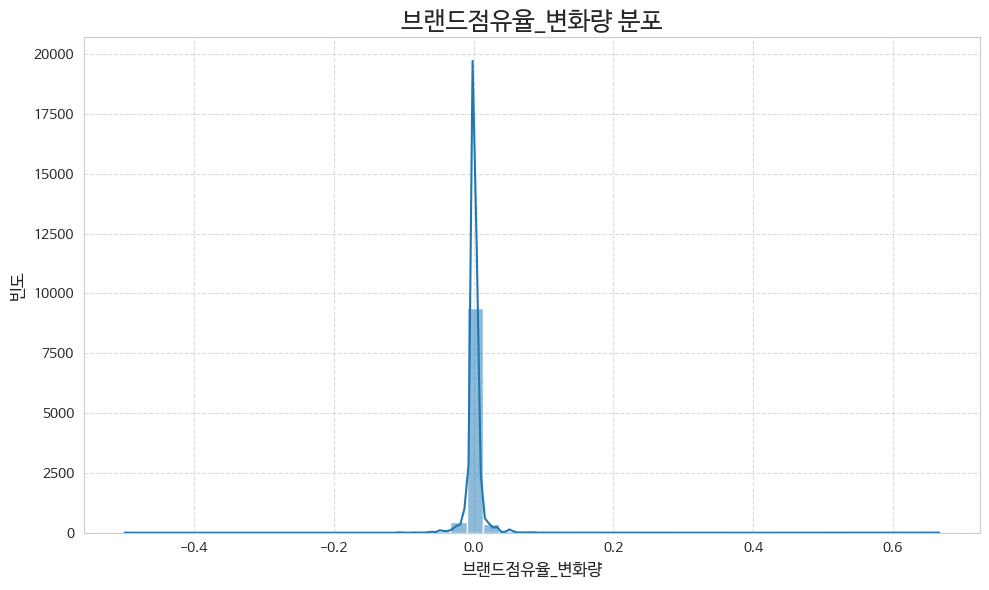

In [ ]:
# 브랜드점유율_변화량 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(model_df["브랜드점유율_변화량"].dropna(), bins=50, kde=True)
plt.title('브랜드점유율_변화량 분포', fontsize=18)
plt.xlabel('브랜드점유율_변화량', fontsize=12)
plt.ylabel('빈도', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 5. 데이터 탐색 및 시각화 (Data Exploration and Visualization)

데이터 전처리 및 병합이 완료된 `model_df`를 활용하여 주요 변수들의 상관관계, 분기별 변화 추이, 그리고 상권 및 매출 현황을 시각적으로 탐색합니다.


In [ ]:
# 나눔바른고딕 폰트 설치
!sudo apt-get install -y fonts-nanum-extra
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 런타임 다시 시작 필요 메시지 출력 (실제로는 코드로 자동 다시 시작하기 어려움)
print("폰트 설치가 완료되었습니다. 한글 폰트 적용을 위해 런타임을 다시 시작해야 합니다. (메뉴: 런타임 > 런타임 다시 시작)")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum-extra is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/true

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Colab 환경)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

print("데이터 상관관계 분석, 중요도, 분기별 인구 변화 및 상권/매출 시각화 시작...")


데이터 상관관계 분석, 중요도, 분기별 인구 변화 및 상권/매출 시각화 시작...


### 5-1. 데이터 상관관계 분석

주요 수치형 변수들 간의 상관관계를 히트맵으로 시각화하여 변수 간의 선형적 관계를 파악합니다. 특히, `점포수_변화량` 및 `성장여부`와 다른 변수들 간의 관계를 집중적으로 살펴봅니다.


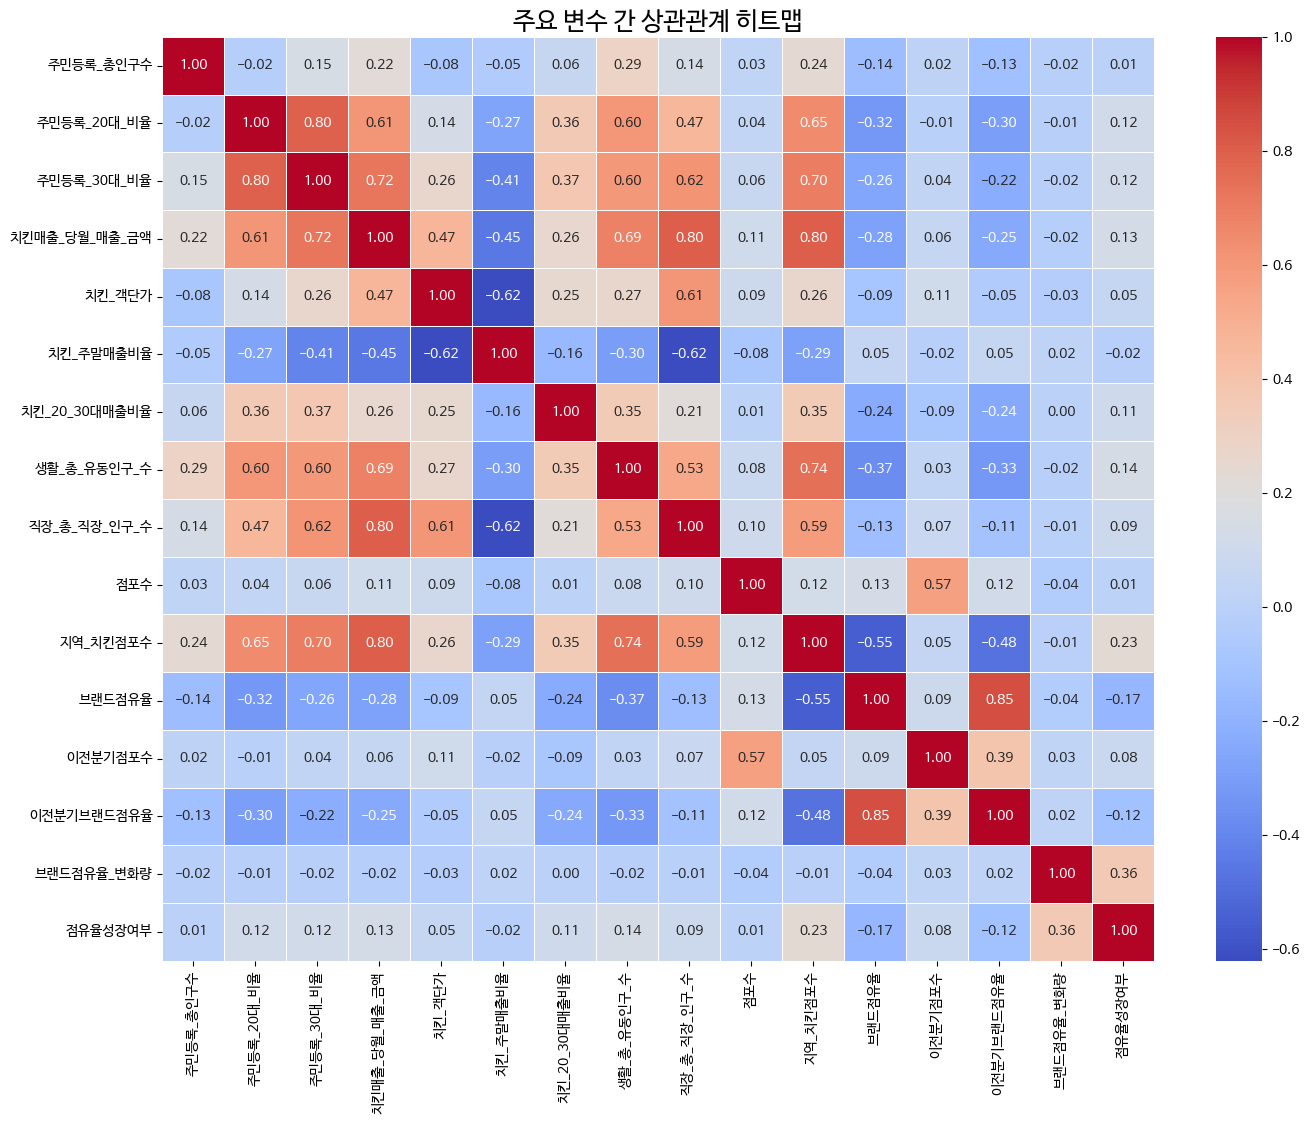

In [ ]:
# 상관관계 분석을 위한 주요 수치형 컬럼 선택
correlation_cols = [
    "주민등록_총인구수", "주민등록_20대_비율", "주민등록_30대_비율",
    "치킨매출_당월_매출_금액", "치킨_객단가", "치킨_주말매출비율", "치킨_20_30대매출비율",
    "생활_총_유동인구_수", # '생활_연령대_평균_연령_대' 컬럼은 model_df에 없어 제외
    "직장_총_직장_인구_수", # '직장_연령대_평균_연령_대' 컬럼은 model_df에 없어 제외
    "점포수", "지역_치킨점포수", "브랜드점유율", "이전분기점포수", "이전분기브랜드점유율",
    "브랜드점유율_변화량", "점유율성장여부"
]

# 선택된 컬럼들로 이루어진 데이터프레임 생성 및 결측치 처리 (상관관계 계산에 방해되지 않도록)
corr_df = model_df[correlation_cols].copy()
corr_df = corr_df.fillna(corr_df.median(numeric_only=True))

# 상관관계 매트릭스 계산
correlation_matrix = corr_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('주요 변수 간 상관관계 히트맵', fontsize=18)
plt.show()


### 5-2. 분기별 인구 변화 추이

분기별 `주민등록_총인구수`, `생활_총생활인구수`, `직장_총직장인구수`의 변화를 시각화하여 인구 구성의 동태적 변화를 파악합니다. 이를 통해 상권 활성화에 영향을 미칠 수 있는 인구 흐름을 이해할 수 있습니다.


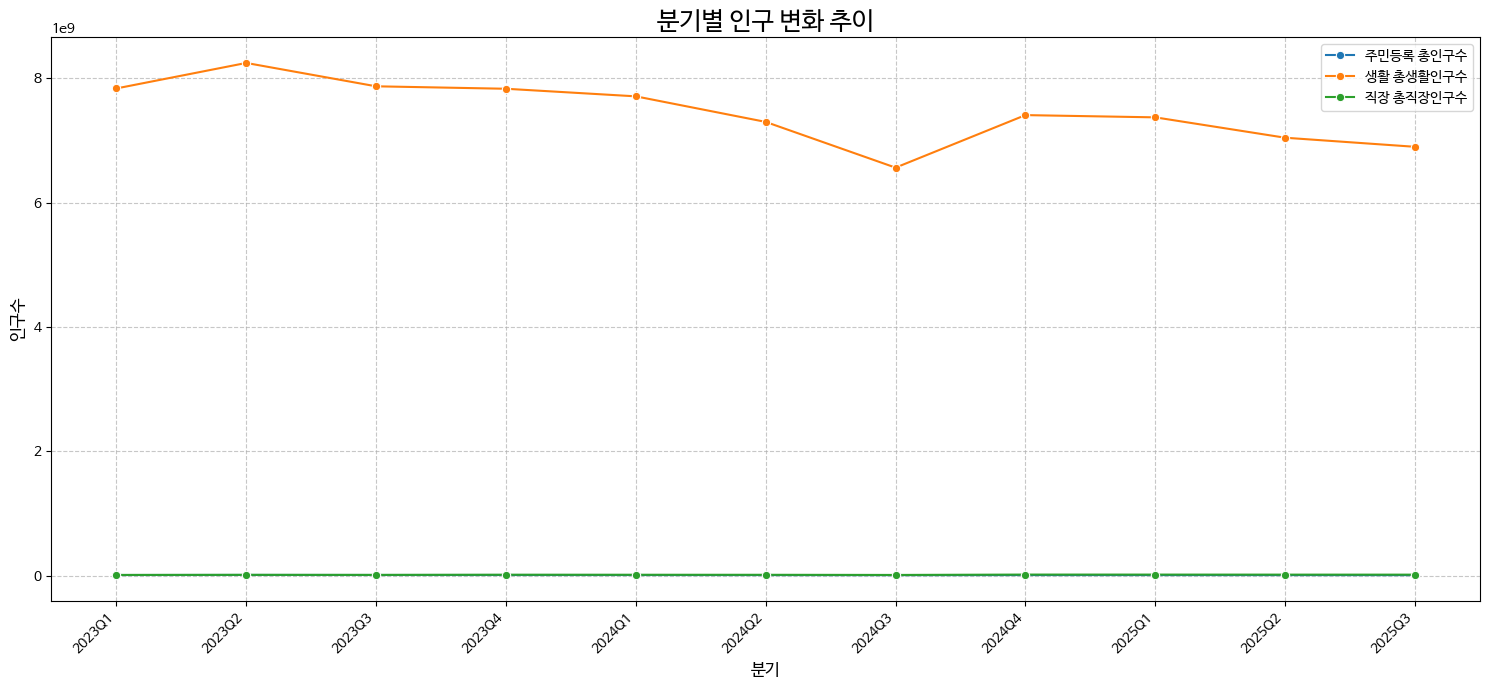

In [ ]:
# 분기별 전체 인구 및 생활/직장 인구 합계 계산
quarterly_population = model_df.groupby("분기순서", as_index=False).agg(
    주민등록_총인구수=('주민등록_총인구수', 'sum'),
    생활_총생활인구수=('생활_총_유동인구_수', 'sum'), # 컬럼 이름 수정
    직장_총직장인구수=('직장_총_직장_인구_수', 'sum') # 컬럼 이름 수정
).sort_values("분기순서")

# 분기 문자열을 다시 생성
quarterly_population['분기'] = quarterly_population['분기순서'].apply(lambda x: f"{x // 4}Q{x % 4 if x % 4 != 0 else 4}" if x % 4 != 0 else f"{x // 4 -1}Q4" )

plt.figure(figsize=(15, 7))
sns.lineplot(x='분기', y='주민등록_총인구수', data=quarterly_population, marker='o', label='주민등록 총인구수')
sns.lineplot(x='분기', y='생활_총생활인구수', data=quarterly_population, marker='o', label='생활 총생활인구수')
sns.lineplot(x='분기', y='직장_총직장인구수', data=quarterly_population, marker='o', label='직장 총직장인구수')

plt.title('분기별 인구 변화 추이', fontsize=18)
plt.xlabel('분기', fontsize=12)
plt.ylabel('인구수', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


### 5-3. 상권 (점포수) 및 매출 변화 추이

분기별 `지역_치킨점포수`와 `치킨매출_당월_매출_금액`의 총합을 시각화하여 치킨 프랜차이즈 시장의 전반적인 동향과 매출 변화를 분석합니다. 또한, 점포수와 매출액 간의 관계를 산점도로 확인합니다.


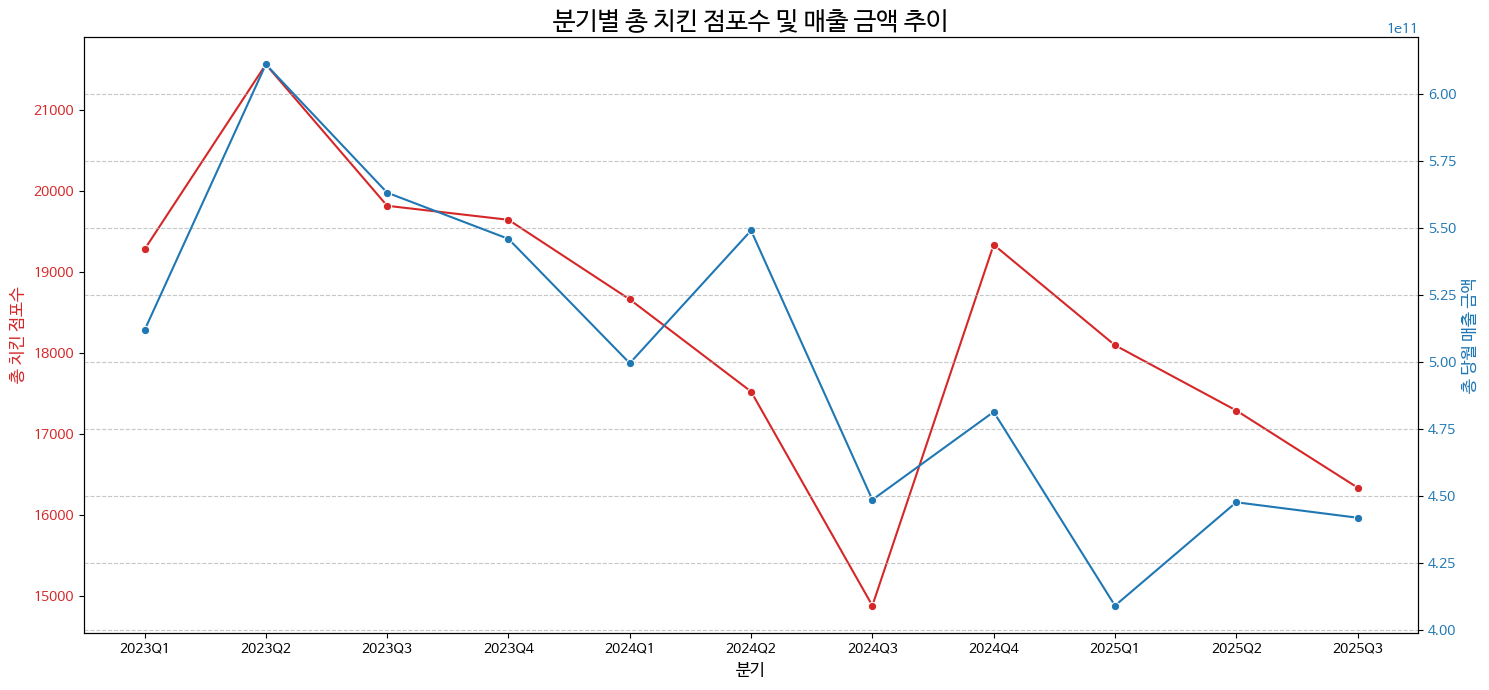

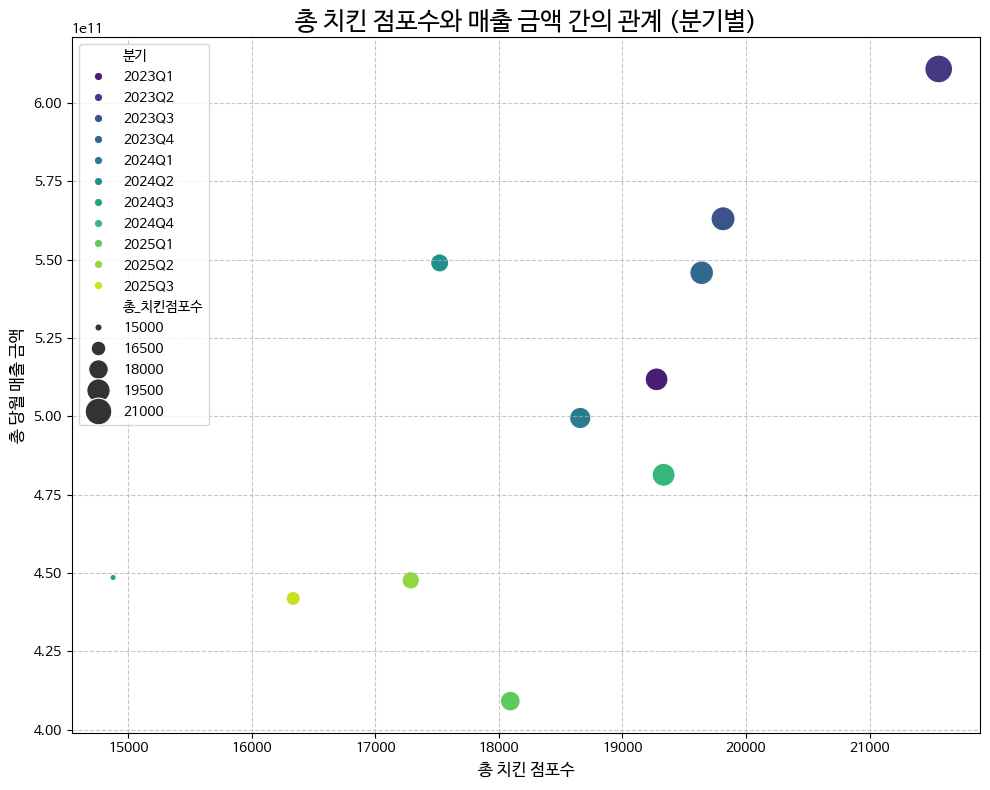

In [ ]:
# 분기별 전체 치킨 점포수 및 매출액 합계 계산
quarterly_store_sales = model_df.groupby("분기순서", as_index=False).agg(
    총_치킨점포수=('지역_치킨점포수', 'sum'), # '지역_치킨점포수'는 이미 각 '시군구명', '행정동명'의 총 점포수이므로, 다시 합산하면 전체 점포수가 됨
    총_당월_매출_금액=('치킨매출_당월_매출_금액', 'sum')
).sort_values("분기순서")

# 분기 문자열 다시 생성
quarterly_store_sales['분기'] = quarterly_store_sales['분기순서'].apply(lambda x: f"{x // 4}Q{x % 4 if x % 4 != 0 else 4}" if x % 4 != 0 else f"{x // 4 -1}Q4" )

# 시각화 1: 분기별 점포수 및 매출액 추이
fig, ax1 = plt.subplots(figsize=(15, 7))

sns.lineplot(x='분기', y='총_치킨점포수', data=quarterly_store_sales, marker='o', color='tab:red', ax=ax1)
ax1.set_xlabel('분기', fontsize=12)
ax1.set_ylabel('총 치킨 점포수', color='tab:red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx() # 두 번째 y축 생성
sns.lineplot(x='분기', y='총_당월_매출_금액', data=quarterly_store_sales, marker='o', color='tab:blue', ax=ax2)
ax2.set_ylabel('총 당월 매출 금액', color='tab:blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('분기별 총 치킨 점포수 및 매출 금액 추이', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 시각화 2: 점포수와 매출액 간의 관계
plt.figure(figsize=(10, 8))
sns.scatterplot(x='총_치킨점포수', y='총_당월_매출_금액', data=quarterly_store_sales, hue='분기', size='총_치킨점포수', sizes=(20, 400), palette='viridis')
plt.title('총 치킨 점포수와 매출 금액 간의 관계 (분기별)', fontsize=18)
plt.xlabel('총 치킨 점포수', fontsize=12)
plt.ylabel('총 당월 매출 금액', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 5. Train/Test 분할

- train: 2023Q1 ~ 2024Q4
- test: 2025Q1 ~ 2025Q3
- 2025Q4는 다음 분기 타깃이 없으므로 자동 제외된다.



In [ ]:
train_df = model_df[model_df["분기"] <= "2024Q4"].copy()
test_df = model_df[(model_df["분기"] >= "2025Q1") & (model_df["분기"] <= "2025Q3")].copy()

print("train:", train_df.shape, train_df["분기"].min(), train_df["분기"].max())
print("test :", test_df.shape, test_df["분기"].min(), test_df["분기"].max())
print("train 성장여부")
display(train_df["점유율성장여부"].value_counts())
print("test 성장여부")
display(test_df["점유율성장여부"].value_counts())

train_df.to_csv(OUT_DIR / "train_data.csv", index=False, encoding="utf-8-sig")
test_df.to_csv(OUT_DIR / "test_data.csv", index=False, encoding="utf-8-sig")



train: (7645, 70) 2023Q1 2024Q4
test : (2750, 70) 2025Q1 2025Q3
train 성장여부


,count
점유율성장여부,
0,4730
1,2915


test 성장여부


,count
점유율성장여부,
0,1821
1,929


## 6. Feature / Target 설정



In [ ]:
drop_cols = [
    "다음분기브랜드점유율",
    "브랜드점유율_변화량",
    "점유율성장여부",
]

categorical_features = ["시군구명", "행정동명", "브랜드", "분기"]
numeric_features = [
    c for c in model_df.columns
    if c not in drop_cols + categorical_features
    and pd.api.types.is_numeric_dtype(model_df[c])
]

feature_cols = categorical_features + numeric_features

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train_cls = train_df["점유율성장여부"].astype(int)
y_test_cls = test_df["점유율성장여부"].astype(int)
y_train_reg = train_df["브랜드점유율_변화량"].astype(float)
y_test_reg = test_df["브랜드점유율_변화량"].astype(float)

print("categorical:", categorical_features)
print("numeric count:", len(numeric_features))
print("numeric sample:", numeric_features[:20])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
    ]
)



categorical: ['시군구명', '행정동명', '브랜드', '분기']
numeric count: 63
numeric sample: ['점포수', '지역_치킨점포수', '지역_브랜드수', '브랜드점유율', '주민등록_총인구수', '주민등록_10대_비율', '주민등록_20대_비율', '주민등록_30대_비율', '주민등록_40대_비율', '주민등록_50대_비율', '주민등록_60대이상_비율', '생활_총_유동인구_수', '생활_연령대_10_유동인구_수', '생활_연령대_20_유동인구_수', '생활_연령대_30_유동인구_수', '생활_연령대_40_유동인구_수', '생활_연령대_50_유동인구_수', '생활_연령대_60_이상_유동인구_수', '생활_연령대_10_유동인구_비율', '생활_연령대_20_유동인구_비율']


## 7. 분류 모델: 성장여부 예측



In [ ]:
neg_count = int((y_train_cls == 0).sum())
pos_count = int((y_train_cls == 1).sum())
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1
print("neg:", neg_count, "pos:", pos_count, "scale_pos_weight:", scale_pos_weight)

classification_models = {
    "RandomForest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=500,
            random_state=SEED,
            class_weight="balanced",
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
    "CatBoost": Pipeline([
        ("preprocess", preprocessor),
        ("model", CatBoostClassifier(
            iterations=500,
            depth=5,
            learning_rate=0.03,
            loss_function="Logloss",
            class_weights=[1, scale_pos_weight],
            random_seed=SEED,
            verbose=False,
        )),
    ]),
}

def get_positive_proba(model, X):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        return proba[:, 1]
    pred = model.predict(X)
    return np.asarray(pred).ravel()

cls_rows = []
cls_pred_frames = []
threshold_grid = np.round(np.arange(0.05, 0.55, 0.05), 2)

for name, model in classification_models.items():
    print(f"\n===== {name} Classification =====")
    model.fit(X_train, y_train_cls)
    y_prob = get_positive_proba(model, X_test)

    best = None
    for th in threshold_grid:
        y_pred = (y_prob >= th).astype(int)
        row = {
            "model": name,
            "threshold": th,
            "accuracy": accuracy_score(y_test_cls, y_pred),
            "precision": precision_score(y_test_cls, y_pred, zero_division=0),
            "recall": recall_score(y_test_cls, y_pred, zero_division=0),
            "f1": f1_score(y_test_cls, y_pred, zero_division=0),
            "predicted_growth_count": int(y_pred.sum()),
        }
        if best is None or row["f1"] > best["f1"]:
            best = row

    y_pred_best = (y_prob >= best["threshold"]).astype(int)
    best["roc_auc"] = roc_auc_score(y_test_cls, y_prob) if y_test_cls.nunique() == 2 else np.nan
    best["pr_auc"] = average_precision_score(y_test_cls, y_prob) if y_test_cls.nunique() == 2 else np.nan
    cls_rows.append(best)

    # Fix: Use existing column names for pred_frame, including '브랜드점유율' and '이전분기브랜드점유율'
    pred_frame = test_df[["분기", "시군구명", "행정동명", "브랜드", "점포수", "브랜드점유율", "이전분기브랜드점유율", "다음분기브랜드점유율", "브랜드점유율_변화량", "점유율성장여부"]].copy()
    pred_frame["model"] = name
    pred_frame["growth_proba"] = y_prob
    pred_frame["threshold"] = best["threshold"]
    pred_frame["pred_growth"] = y_pred_best
    # Fix: Correct column name for comparison
    pred_frame["correct"] = pred_frame["점유율성장여부"] == pred_frame["pred_growth"]
    cls_pred_frames.append(pred_frame)

    print("best threshold:", best["threshold"])
    print(confusion_matrix(y_test_cls, y_pred_best))
    print(classification_report(y_test_cls, y_pred_best, zero_division=0))

cls_metrics = pd.DataFrame(cls_rows).sort_values("f1", ascending=False)
cls_preds = pd.concat(cls_pred_frames, ignore_index=True)

display(cls_metrics)
cls_metrics.to_csv(OUT_DIR / "classification_metrics.csv", index=False, encoding="utf-8-sig")
cls_preds.to_csv(OUT_DIR / "classification_predictions.csv", index=False, encoding="utf-8-sig")


neg: 4730 pos: 2915 scale_pos_weight: 1.6226415094339623

===== RandomForest Classification =====
best threshold: 0.05
[[   1 1820]
 [   0  929]]
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      1821
           1       0.34      1.00      0.51       929

    accuracy                           0.34      2750
   macro avg       0.67      0.50      0.25      2750
weighted avg       0.78      0.34      0.17      2750


===== XGBoost Classification =====
best threshold: 0.1
[[ 186 1635]
 [  40  889]]
              precision    recall  f1-score   support

           0       0.82      0.10      0.18      1821
           1       0.35      0.96      0.51       929

    accuracy                           0.39      2750
   macro avg       0.59      0.53      0.35      2750
weighted avg       0.66      0.39      0.29      2750


===== CatBoost Classification =====
best threshold: 0.2
[[ 639 1182]
 [ 168  761]]
              precision    recall

,model,threshold,accuracy,precision,recall,f1,predicted_growth_count,roc_auc,pr_auc
2,CatBoost,0.20,0.509091,0.391662,0.819160,0.529944,1943,0.579409,0.438536
1,XGBoost,0.10,0.390909,0.352219,0.956943,0.514915,2524,0.551274,0.402403
0,RandomForest,0.05,0.338182,0.337941,1.000000,0.505166,2749,0.556943,0.415167


## 8. 회귀 모델: 점포수 변화량 예측



In [ ]:
regression_models = {
    "RandomForest": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=500,
            random_state=SEED,
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ]),
    "XGBoost": Pipeline([
        ("preprocess", preprocessor),
        ("model", XGBRegressor(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.03,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
        )),
    ]),
    "CatBoost": Pipeline([
        ("preprocess", preprocessor),
        ("model", CatBoostRegressor(
            iterations=500,
            depth=5,
            learning_rate=0.03,
            loss_function="RMSE",
            random_seed=SEED,
            verbose=False,
        )),
    ]),
}

reg_rows = []
reg_pred_frames = []

for name, model in regression_models.items():
    print(f"\n===== {name} Regression =====")
    model.fit(X_train, y_train_reg)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred)) # squared=False 제거 및 np.sqrt 추가
    row = {
        "model": name,
        "mae": mean_absolute_error(y_test_reg, y_pred),
        "rmse": rmse,
        "r2": r2_score(y_test_reg, y_pred),
    }
    reg_rows.append(row)

    # Fix: Use existing column names for pred_frame
    pred_frame = test_df[["분기", "시군구명", "행정동명", "브랜드", "점포수", "다음분기브랜드점유율", "브랜드점유율_변화량", "점유율성장여부"]].copy()
    pred_frame["model"] = name
    pred_frame["pred_change"] = y_pred
    pred_frame["abs_error"] = (pred_frame["브랜드점유율_변화량"] - pred_frame["pred_change"]).abs()
    reg_pred_frames.append(pred_frame)

reg_metrics = pd.DataFrame(reg_rows).sort_values("rmse")
reg_preds = pd.concat(reg_pred_frames, ignore_index=True)

display(reg_metrics)
reg_metrics.to_csv(OUT_DIR / "regression_metrics.csv", index=False, encoding="utf-8-sig")
reg_preds.to_csv(OUT_DIR / "regression_predictions.csv", index=False, encoding="utf-8-sig")



===== RandomForest Regression =====

===== XGBoost Regression =====

===== CatBoost Regression =====


,model,mae,rmse,r2
1,XGBoost,0.005384,0.010499,-0.233671
0,RandomForest,0.005860,0.010767,-0.297543
2,CatBoost,0.005321,0.011551,-0.493216


## 10. 전체 성능표 통합



In [ ]:
final_cls_metrics = cls_metrics.sort_values("f1", ascending=False)
final_reg_metrics = reg_metrics.sort_values("rmse")

display(final_cls_metrics)
display(final_reg_metrics)

final_cls_metrics.to_csv(OUT_DIR / "final_classification_metrics_all_models.csv", index=False, encoding="utf-8-sig")
final_reg_metrics.to_csv(OUT_DIR / "final_regression_metrics_all_models.csv", index=False, encoding="utf-8-sig")


,model,threshold,accuracy,precision,recall,f1,predicted_growth_count,roc_auc,pr_auc
2,CatBoost,0.20,0.509091,0.391662,0.819160,0.529944,1943,0.579409,0.438536
1,XGBoost,0.10,0.390909,0.352219,0.956943,0.514915,2524,0.551274,0.402403
0,RandomForest,0.05,0.338182,0.337941,1.000000,0.505166,2749,0.556943,0.415167


,model,mae,rmse,r2
1,XGBoost,0.005384,0.010499,-0.233671
0,RandomForest,0.005860,0.010767,-0.297543
2,CatBoost,0.005321,0.011551,-0.493216


## 11. 잘 맞힌 사례 / 틀린 사례 출력



In [ ]:
def show_classification_cases(pred_df, model_name=None, n=10):
    df = pred_df.copy()
    if model_name is not None:
        df = df[df["model"] == model_name].copy()
    if df.empty:
        print("출력할 분류 예측 결과가 없습니다.")
        return

    correct = df[df["correct"]].sort_values("growth_proba", ascending=False)
    wrong = df[~df["correct"]].copy()
    wrong["error_type"] = np.where(
        (wrong["점유율성장여부"] == 1) & (wrong["pred_growth"] == 0),
        "실제 성장인데 미성장으로 예측",
        "실제 미성장인데 성장으로 예측",
    )
    wrong = wrong.sort_values("growth_proba", ascending=False)

    print("\n[분류] 잘 맞힌 사례")
    display(correct[["model", "분기", "시군구명", "행정동명", "브랜드", "브랜드점유율", "이전분기브랜드점유율", "브랜드점유율_변화량", "점유율성장여부", "pred_growth", "growth_proba"]].head(n))

    print("\n[분류] 틀린 사례")
    display(wrong[["model", "분기", "시군구명", "행정동명", "브랜드", "브랜드점유율", "이전분기브랜드점유율", "브랜드점유율_변화량", "점유율성장여부", "pred_growth", "growth_proba", "error_type"]].head(n))

def show_regression_cases(pred_df, model_name=None, n=10):
    df = pred_df.copy()
    if model_name is not None:
        df = df[df["model"] == model_name].copy()
    if df.empty:
        print("출력할 회귀 예측 결과가 없습니다.")
        return

    correct = df.sort_values("abs_error", ascending=True)
    wrong = df.sort_values("abs_error", ascending=False)

    print("\n[회귀] 잘 맞힌 사례: 절대오차 작은 순")
    # Fix: Use '다음분기브랜드점유율' and '브랜드점유율_변화량' instead of missing '다음분기점포수' and '점포수_변화량'
    display(correct[["model", "분기", "시군구명", "행정동명", "브랜드", "점포수", "다음분기브랜드점유율", "브랜드점유율_변화량", "pred_change", "abs_error"]].head(n))

    print("\n[회귀] 틀린 사례: 절대오차 큰 순")
    # Fix: Use '다음분기브랜드점유율' and '브랜드점유율_변화량' instead of missing '다음분기점포수' and '점포수_변화량'
    display(wrong[["model", "분기", "시군구명", "행정동명", "브랜드", "점포수", "다음분기브랜드점유율", "브랜드점유율_변화량", "pred_change", "abs_error"]].head(n))

# 트리 모델 사례
show_classification_cases(cls_preds, n=10)
show_regression_cases(reg_preds, n=10)

# LSTM 사례
if (OUT_DIR / "lstm_classification_predictions.csv").exists():
    lstm_cls_pred_loaded = pd.read_csv(OUT_DIR / "lstm_classification_predictions.csv")
    show_classification_cases(lstm_cls_pred_loaded, model_name="LSTM", n=10)

if (OUT_DIR / "lstm_regression_predictions.csv").exists():
    lstm_reg_pred_loaded = pd.read_csv(OUT_DIR / "lstm_regression_predictions.csv")
    show_regression_cases(lstm_reg_pred_loaded, model_name="LSTM", n=10)



[분류] 잘 맞힌 사례


,model,분기,시군구명,행정동명,브랜드,브랜드점유율,이전분기브랜드점유율,브랜드점유율_변화량,점유율성장여부,pred_growth,growth_proba
6099,CatBoost,2025Q1,강남구,역삼1동,나이티지,0.037037,0.033333,0.001425,1,1,0.944999
6067,CatBoost,2025Q1,강남구,역삼1동,BBQ,0.037037,0.033333,0.001425,1,1,0.941921
6068,CatBoost,2025Q2,강남구,역삼1동,BBQ,0.038462,0.037037,0.002355,1,1,0.941714
6186,CatBoost,2025Q1,강남구,역삼1동,한앤둘치킨,0.037037,0.033333,0.001425,1,1,0.940077
6187,CatBoost,2025Q2,강남구,역삼1동,한앤둘치킨,0.038462,0.037037,0.002355,1,1,0.939864
6079,CatBoost,2025Q1,강남구,역삼1동,교촌치킨,0.037037,0.033333,0.001425,1,1,0.936831
6080,CatBoost,2025Q2,강남구,역삼1동,교촌치킨,0.038462,0.037037,0.002355,1,1,0.936608
6124,CatBoost,2025Q2,강남구,역삼1동,둘둘치킨,0.019231,0.018519,0.001177,1,1,0.936594
6190,CatBoost,2025Q2,강남구,역삼1동,후라이드참잘하는집,0.019231,0.018519,0.001177,1,1,0.936594
6154,CatBoost,2025Q2,강남구,역삼1동,육품88,0.019231,0.018519,0.001177,1,1,0.936594



[분류] 틀린 사례


,model,분기,시군구명,행정동명,브랜드,브랜드점유율,이전분기브랜드점유율,브랜드점유율_변화량,점유율성장여부,pred_growth,growth_proba,error_type
6101,CatBoost,2025Q3,강남구,역삼1동,나이티지,0.020408,0.038462,-0.000408,0,1,0.951712,실제 미성장인데 성장으로 예측
6100,CatBoost,2025Q2,강남구,역삼1동,나이티지,0.038462,0.037037,-0.018053,0,1,0.944803,실제 미성장인데 성장으로 예측
7981,CatBoost,2025Q1,강서구,화곡1동,호식이두마리치킨,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7935,CatBoost,2025Q1,강서구,화곡1동,내가강정이닭,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7938,CatBoost,2025Q1,강서구,화곡1동,네네치킨,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7987,CatBoost,2025Q1,강서구,화곡1동,화신바베큐치킨,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7932,CatBoost,2025Q1,강서구,화곡1동,굽네치킨,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7926,CatBoost,2025Q1,강서구,화곡1동,BHC,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7941,CatBoost,2025Q1,강서구,화곡1동,누구나홀딱반한닭,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7964,CatBoost,2025Q1,강서구,화곡1동,인생닭강정,0.043478,0.041667,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측



[회귀] 잘 맞힌 사례: 절대오차 작은 순


,model,분기,시군구명,행정동명,브랜드,점포수,다음분기브랜드점유율,브랜드점유율_변화량,pred_change,abs_error
3968,XGBoost,2025Q1,강동구,암사1동,굽네치킨,2,0.105263,0.000000,4.186545e-07,4.186545e-07
2668,RandomForest,2025Q3,강서구,화곡6동,푸라닭,1,0.062500,0.003676,3.674700e-03,1.770160e-06
3565,XGBoost,2025Q3,강동구,강일동,교촌치킨,2,0.166667,0.000000,-1.828880e-05,1.828880e-05
2113,RandomForest,2025Q1,강서구,등촌2동,이나닭강정,1,0.142857,0.000000,-1.996527e-05,1.996527e-05
235,RandomForest,2025Q3,강남구,대치2동,교촌치킨,1,0.050000,0.000000,-2.007058e-05,2.007058e-05
434,RandomForest,2025Q3,강남구,세곡동,가마치통닭,1,0.062500,0.003676,3.646006e-03,3.046478e-05
7902,CatBoost,2025Q1,강서구,우장산동,비에이치시,1,0.058824,0.003268,3.235357e-03,3.261693e-05
7905,CatBoost,2025Q1,강서구,우장산동,오븐마루,1,0.058824,0.003268,3.235357e-03,3.261693e-05
7923,CatBoost,2025Q1,강서구,우장산동,후라이드참잘하는집,1,0.058824,0.003268,3.235357e-03,3.261693e-05
7896,CatBoost,2025Q1,강서구,우장산동,또봉이통닭내,1,0.058824,0.003268,3.235357e-03,3.261693e-05



[회귀] 틀린 사례: 절대오차 큰 순


,model,분기,시군구명,행정동명,브랜드,점포수,다음분기브랜드점유율,브랜드점유율_변화량,pred_change,abs_error
7033,CatBoost,2025Q3,강북구,번2동,굽네치킨,1,1.000000,0.000000,0.248547,0.248547
7032,CatBoost,2025Q2,강북구,번2동,굽네치킨,1,1.000000,0.000000,0.130838,0.130838
4340,XGBoost,2025Q1,강북구,삼양동,BBQ,1,0.250000,0.125000,-0.003168,0.128168
7090,CatBoost,2025Q1,강북구,삼양동,BBQ,1,0.250000,0.125000,-0.003125,0.128125
1590,RandomForest,2025Q1,강북구,삼양동,BBQ,1,0.250000,0.125000,-0.000100,0.125100
3797,XGBoost,2025Q1,강동구,명일2동,네네치킨,2,0.400000,0.000000,-0.099748,0.099748
1534,RandomForest,2025Q1,강북구,번3동,BBQ,1,0.222222,0.097222,0.002278,0.094944
4284,XGBoost,2025Q1,강북구,번3동,BBQ,1,0.222222,0.097222,0.003889,0.093333
7034,CatBoost,2025Q1,강북구,번3동,BBQ,1,0.222222,0.097222,0.004304,0.092918
3798,XGBoost,2025Q2,강동구,명일2동,네네치킨,2,0.400000,0.000000,-0.091576,0.091576


## 12. 최종정리


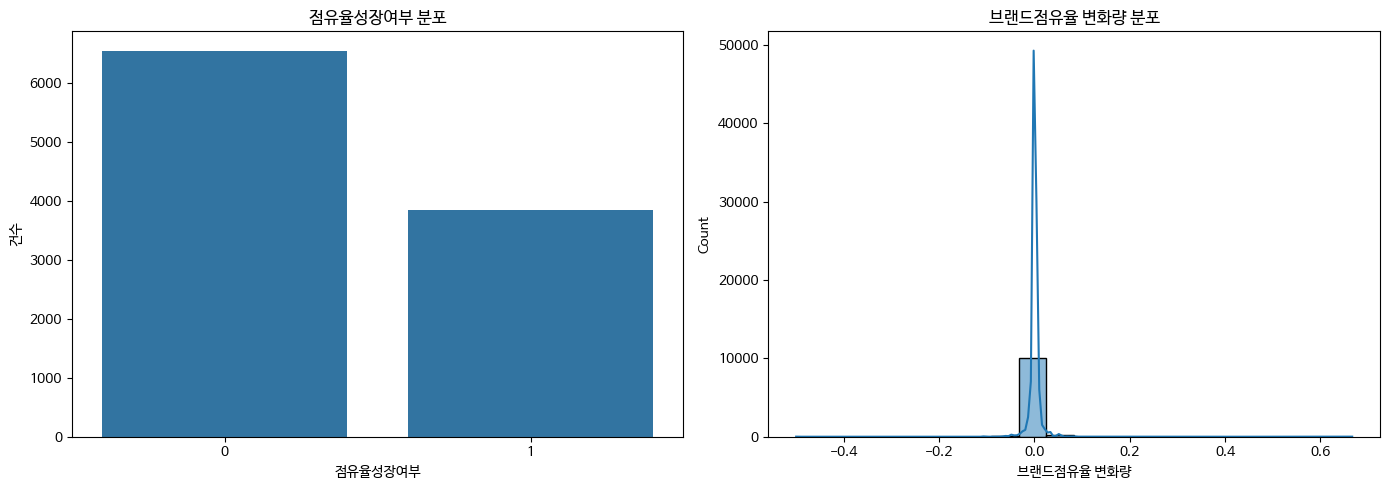

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=model_df, x="점유율성장여부", ax=axes[0])
axes[0].set_title("점유율성장여부 분포")
axes[0].set_xlabel("점유율성장여부")
axes[0].set_ylabel("건수")

sns.histplot(data=model_df, x="브랜드점유율_변화량", bins=20, kde=True, ax=axes[1])
axes[1].set_title("브랜드점유율 변화량 분포")
axes[1].set_xlabel("브랜드점유율 변화량")

plt.tight_layout()
plt.show()


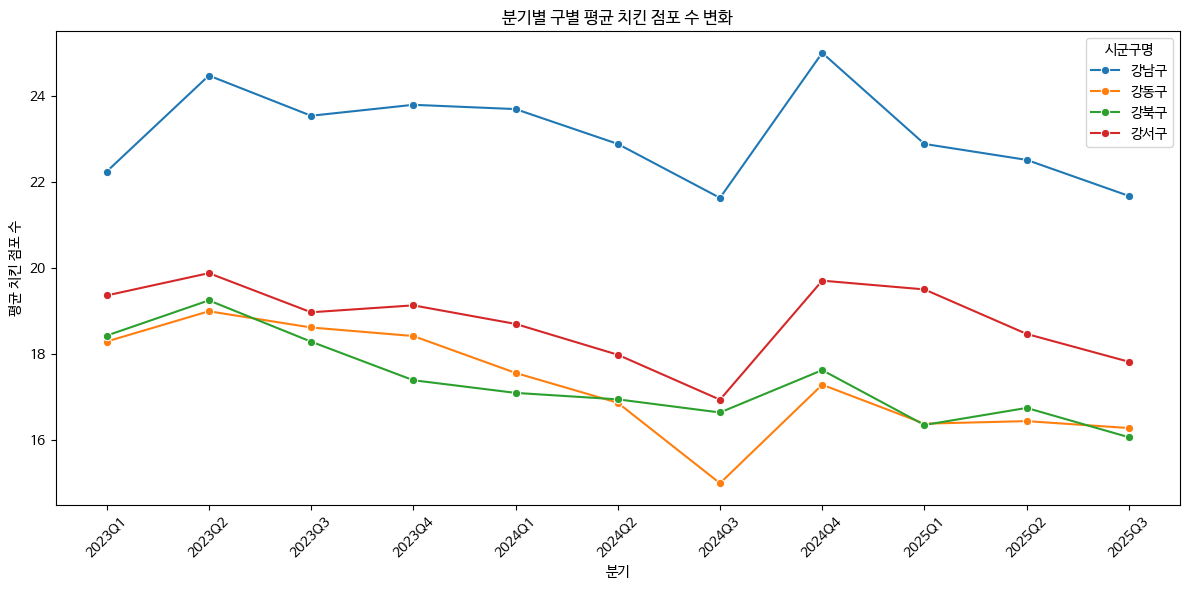

In [ ]:
area_trend = (
    model_df.groupby(["분기", "시군구명"], as_index=False)["지역_치킨점포수"]
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=area_trend, x="분기", y="지역_치킨점포수", hue="시군구명", marker="o")
plt.title("분기별 구별 평균 치킨 점포 수 변화")
plt.xlabel("분기")
plt.ylabel("평균 치킨 점포 수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


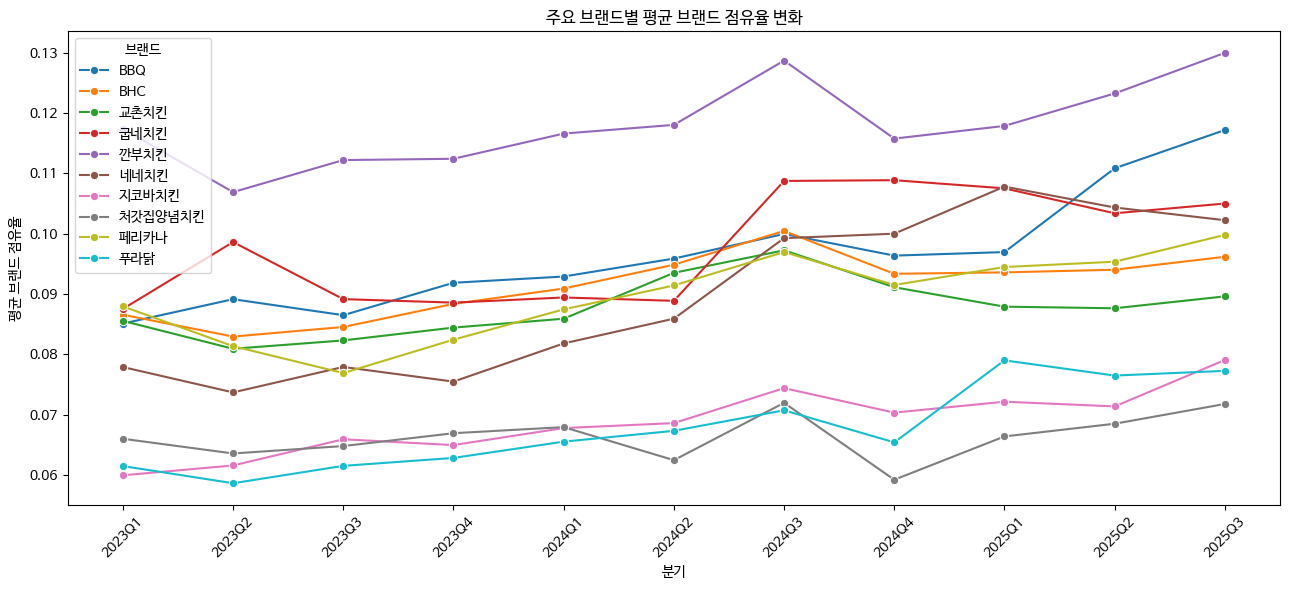

In [ ]:
top_brands = (
    model_df.groupby("브랜드")["점포수"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

brand_trend = (
    model_df[model_df["브랜드"].isin(top_brands)]
    .groupby(["분기", "브랜드"], as_index=False)["브랜드점유율"]
    .mean()
)

plt.figure(figsize=(13, 6))
sns.lineplot(data=brand_trend, x="분기", y="브랜드점유율", hue="브랜드", marker="o")
plt.title("주요 브랜드별 평균 브랜드 점유율 변화")
plt.xlabel("분기")
plt.ylabel("평균 브랜드 점유율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


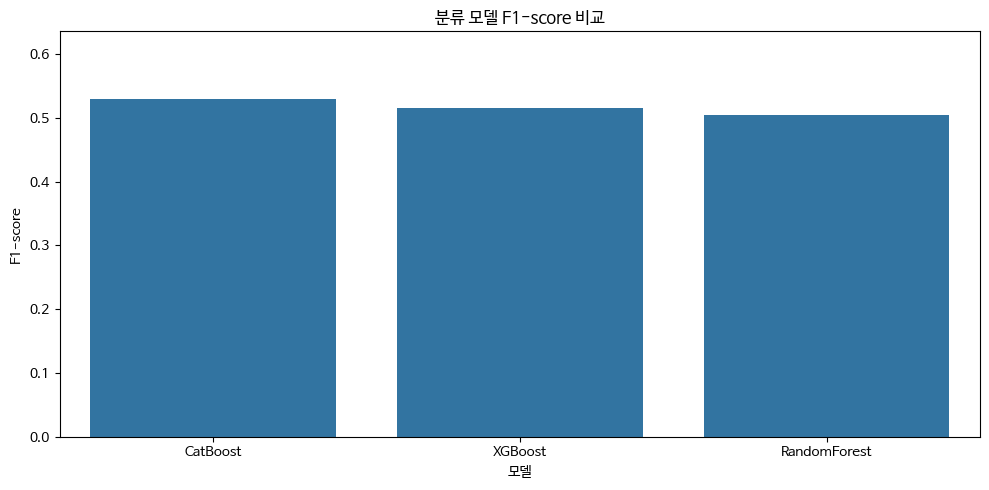

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_cls_metrics, x="model", y="f1")
plt.title("분류 모델 F1-score 비교")
plt.xlabel("모델")
plt.ylabel("F1-score")
plt.ylim(0, max(final_cls_metrics["f1"].max() * 1.2, 0.1))
plt.tight_layout()
plt.show()


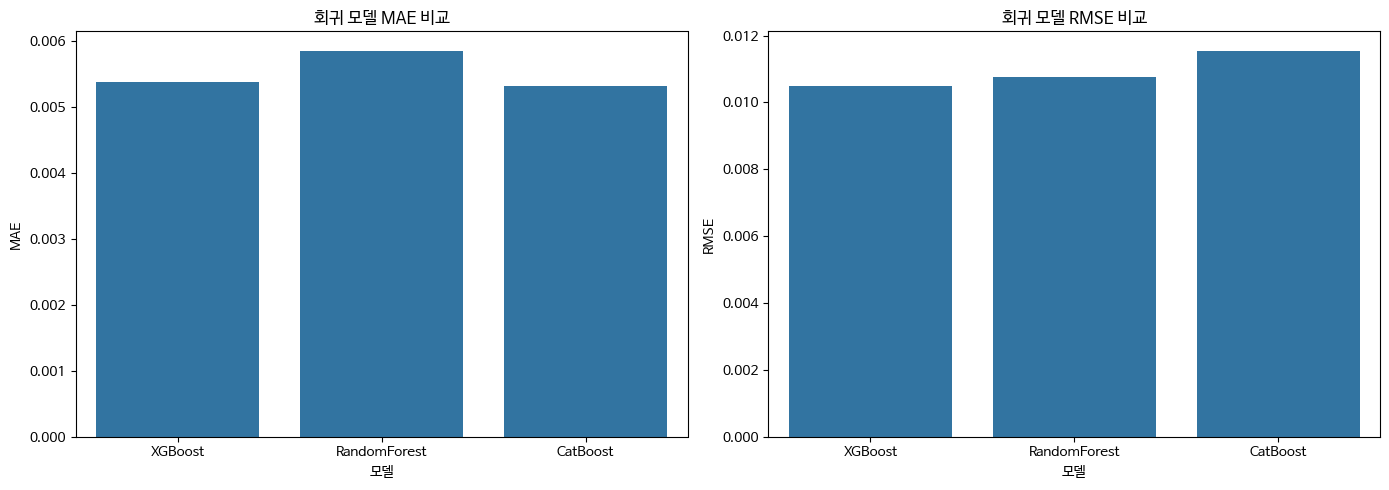

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=final_reg_metrics, x="model", y="mae", ax=axes[0])
axes[0].set_title("회귀 모델 MAE 비교")
axes[0].set_xlabel("모델")
axes[0].set_ylabel("MAE")

sns.barplot(data=final_reg_metrics, x="model", y="rmse", ax=axes[1])
axes[1].set_title("회귀 모델 RMSE 비교")
axes[1].set_xlabel("모델")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()


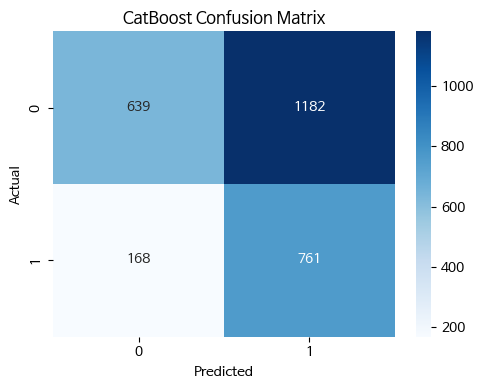

In [ ]:
best_cls_model = final_cls_metrics.sort_values("f1", ascending=False).iloc[0]["model"]

best_cls_pred = cls_preds[cls_preds["model"] == best_cls_model].copy()

cm = confusion_matrix(best_cls_pred["점유율성장여부"], best_cls_pred["pred_growth"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_cls_model} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


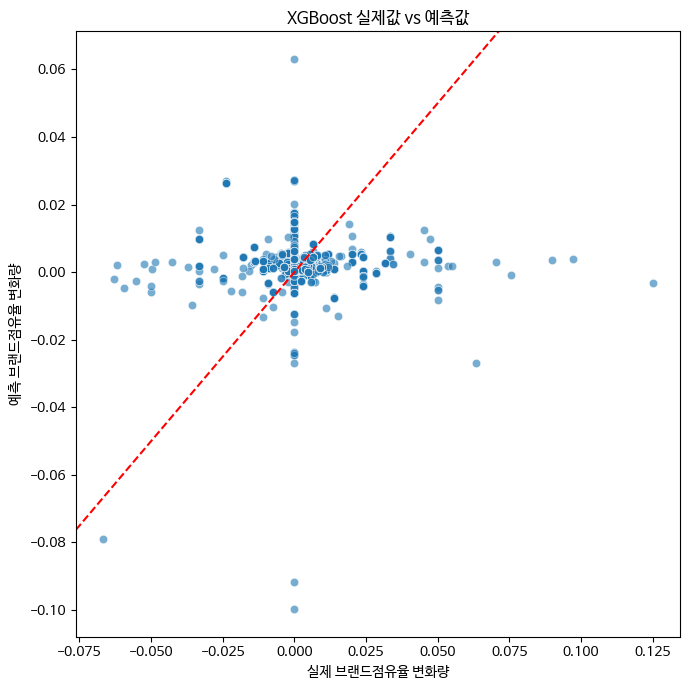

In [ ]:
best_reg_model = final_reg_metrics.sort_values("rmse").iloc[0]["model"]

best_reg_pred = reg_preds[reg_preds["model"] == best_reg_model].copy()

plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_reg_pred, x="브랜드점유율_변화량", y="pred_change", alpha=0.6)
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.title(f"{best_reg_model} 실제값 vs 예측값")
plt.xlabel("실제 브랜드점유율 변화량")
plt.ylabel("예측 브랜드점유율 변화량")
plt.tight_layout()
plt.show()


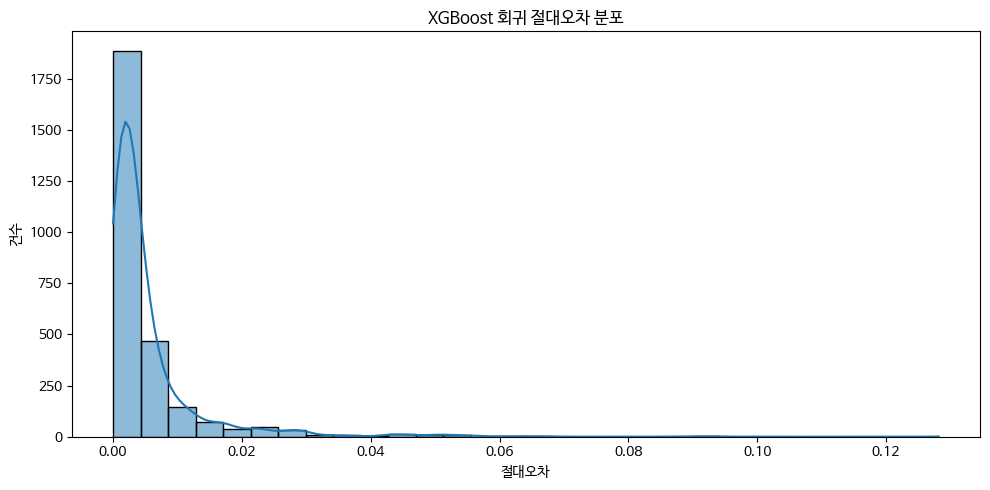

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=best_reg_pred, x="abs_error", bins=30, kde=True)
plt.title(f"{best_reg_model} 회귀 절대오차 분포")
plt.xlabel("절대오차")
plt.ylabel("건수")
plt.tight_layout()
plt.show()


###Feature Importance


In [ ]:
def get_feature_names_from_pipeline(pipeline, categorical_features, numeric_features):
    preprocessor = pipeline.named_steps["preprocess"]
    cat_encoder = preprocessor.named_transformers_["cat"]
    cat_names = cat_encoder.get_feature_names_out(categorical_features)
    return np.concatenate([cat_names, numeric_features])

def plot_feature_importance(model_dict, model_name, categorical_features, numeric_features, top_n=20):
    pipeline = model_dict[model_name]
    feature_names = get_feature_names_from_pipeline(
        pipeline, categorical_features, numeric_features
    )
    estimator = pipeline.named_steps["model"]

    if not hasattr(estimator, "feature_importances_"):
        print(f"{model_name}은 feature_importances_를 지원하지 않습니다.")
        return

    importance = estimator.feature_importances_

    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    }).sort_values("importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi, x="importance", y="feature")
    plt.title(f"{model_name} Feature Importance Top {top_n}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return fi


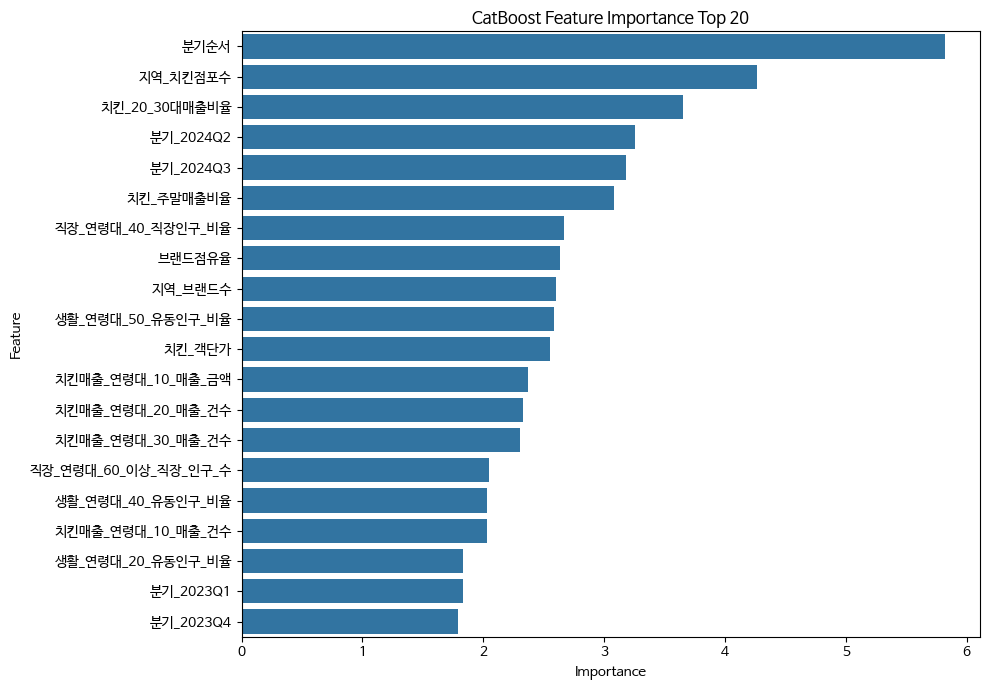

,feature,importance
753,분기순서,5.819497
694,지역_치킨점포수,4.267826
752,치킨_20_30대매출비율,3.649930
690,분기_2024Q2,3.256621
691,분기_2024Q3,3.179322
751,치킨_주말매출비율,3.082898
727,직장_연령대_40_직장인구_비율,2.666367
696,브랜드점유율,2.635955
695,지역_브랜드수,2.602788
715,생활_연령대_50_유동인구_비율,2.586834


In [ ]:
best_tree_cls = final_cls_metrics[
    final_cls_metrics["model"].isin(["RandomForest", "XGBoost", "CatBoost"])
].sort_values("f1", ascending=False).iloc[0]["model"]

cls_fi = plot_feature_importance(
    classification_models,
    best_tree_cls,
    categorical_features,
    numeric_features,
    top_n=20
)

display(cls_fi)


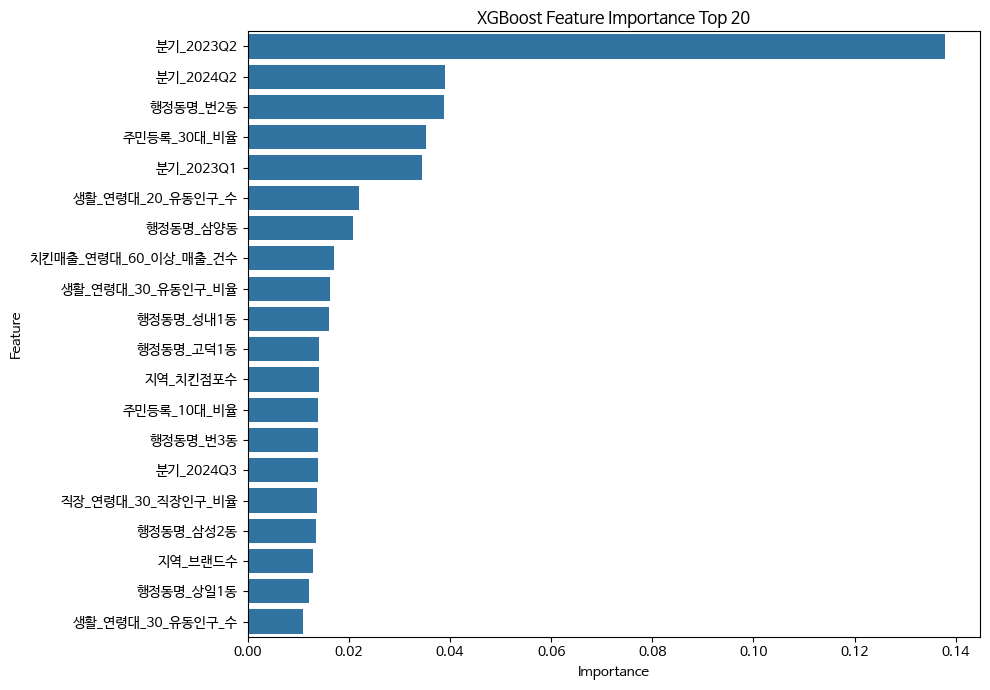

,feature,importance
686,분기_2023Q2,0.137898
690,분기_2024Q2,0.039114
34,행정동명_번2동,0.038810
700,주민등록_30대_비율,0.035251
685,분기_2023Q1,0.034377
706,생활_연령대_20_유동인구_수,0.022014
39,행정동명_삼양동,0.020749
749,치킨매출_연령대_60_이상_매출_건수,0.017137
713,생활_연령대_30_유동인구_비율,0.016262
42,행정동명_성내1동,0.016091


In [ ]:
best_tree_reg = final_reg_metrics[
    final_reg_metrics["model"].isin(["RandomForest", "XGBoost", "CatBoost"])
].sort_values("rmse").iloc[0]["model"]

reg_fi = plot_feature_importance(
    regression_models,
    best_tree_reg,
    categorical_features,
    numeric_features,
    top_n=20
)

display(reg_fi)


## 13. 보고서용 표·그림 자산 저장

최종 보고서에 바로 첨부할 표와 그림을 별도 파일로 저장한다.

생성 목록
- [표 2-1] 원천 데이터 구성
- [표 2-2] 데이터 전처리 과정
- [표 2-4] Feature 및 Target 변수 정의
- [표 2-7] 학습·검증·테스트 데이터 분할
- [그림 3-1] 분기별 브랜드 점유율 변화
- [그림 3-4] 브랜드점유율 변화량 분포
- [그림 3-5] 점유율성장여부 클래스 분포
- [그림 3-13] 주요 변수 간 상관관계
- [표 3-1] 분류 모델 성능 비교
- [표 3-2] 회귀 모델 성능 비교
- [그림 3-7] Confusion Matrix
- [그림 3-9] 실제값 vs 예측값
- [그림 3-11] 분류 모델 Feature Importance
- [그림 3-12] 회귀 모델 Feature Importance
- [표 3-3] 잘 맞힌 사례
- [표 3-5] 틀린 사례
- [표 4-1] 결론 및 활용 방안


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

REPORT_DIR = Path('/content/report_assets') if Path('/content').exists() else Path.cwd() / 'report_assets'
REPORT_DIR.mkdir(exist_ok=True)

plt.rcParams['axes.unicode_minus'] = False
for font_name in ['Malgun Gothic', 'NanumGothic', 'AppleGothic']:
    plt.rcParams['font.family'] = font_name
    break
sns.set_style('whitegrid')

print('보고서용 자산 저장 폴더:', REPORT_DIR)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지


보고서용 자산 저장 폴더: /content/report_assets


### 13-1. 보고서 2장 표 저장


In [ ]:
report_table_2_1 = pd.DataFrame([
    {'데이터명':'치킨전문점 매출 데이터', '주요 변수':'분기, 자치구, 행정동, 매출금액, 매출건수', '분석 단위':'분기-행정동', '활용 목적':'상권 매출 특성 반영'},
    {'데이터명':'가맹점 점포수 데이터', '주요 변수':'분기, 시군구명, 행정동명, 브랜드, 점포수', '분석 단위':'분기-브랜드', '활용 목적':'브랜드 점유율 산출'},
    {'데이터명':'주민등록 인구 데이터', '주요 변수':'총인구수, 연령대별 인구 비율', '분석 단위':'분기-행정동', '활용 목적':'지역 인구 구조 반영'},
    {'데이터명':'생활인구 데이터', '주요 변수':'유동인구수, 연령대별 유동인구 비율', '분석 단위':'분기-행정동', '활용 목적':'생활권 수요 특성 반영'},
    {'데이터명':'직장인구 데이터', '주요 변수':'직장인구수, 연령대별 직장인구 비율', '분석 단위':'분기-행정동', '활용 목적':'업무지 수요 특성 반영'},
])
report_table_2_1.to_csv(REPORT_DIR / '표_2-1_원천_데이터_구성.csv', index=False, encoding='utf-8-sig')
display(report_table_2_1)

report_table_2_2 = pd.DataFrame([
    {'전처리 단계':'분기 형식 통일', '처리 내용':'20231 등의 값을 2023Q1 형식으로 변환', '목적':'데이터 병합 기준 통일'},
    {'전처리 단계':'텍스트 정제', '처리 내용':'자치구명, 행정동명, 브랜드명 공백 및 표기 정리', '목적':'동일 지역·브랜드 매칭 정확도 향상'},
    {'전처리 단계':'브랜드명 정규화', '처리 내용':'지점명이 포함된 상호명을 대표 브랜드명으로 통일', '목적':'브랜드 단위 분석 가능'},
    {'전처리 단계':'수치형 변환', '처리 내용':'매출, 인구, 점포수 등 numeric 컬럼 변환', '목적':'모델 학습 입력값 구성'},
    {'전처리 단계':'파생 변수 생성', '처리 내용':'브랜드점유율, 이전분기점유율, 다음분기점유율, 변화량 생성', '목적':'예측 Target 및 설명 변수 구성'},
])
report_table_2_2.to_csv(REPORT_DIR / '표_2-2_데이터_전처리_과정.csv', index=False, encoding='utf-8-sig')
display(report_table_2_2)

report_table_2_4 = pd.DataFrame([
    {'구분':'범주형 Feature', '변수명':'시군구명, 행정동명, 브랜드, 분기', '설명':'지역·브랜드·시점 특성'},
    {'구분':'점포 Feature', '변수명':'점포수, 지역_치킨점포수, 지역_브랜드수, 브랜드점유율', '설명':'상권 내 경쟁 구조와 현재 점유율'},
    {'구분':'매출 Feature', '변수명':'치킨_객단가, 치킨_주말매출비율, 치킨_20_30대매출비율', '설명':'치킨 업종 매출 특성'},
    {'구분':'인구 Feature', '변수명':'주민등록_총인구수 및 연령대별 비율', '설명':'상주 인구 구조'},
    {'구분':'생활인구 Feature', '변수명':'생활_총_유동인구_수 및 연령대별 비율', '설명':'유동 수요 특성'},
    {'구분':'직장인구 Feature', '변수명':'직장_총_직장_인구_수 및 연령대별 비율', '설명':'업무지 수요 특성'},
    {'구분':'분류 Target', '변수명':'점유율성장여부', '설명':'다음 분기 브랜드점유율 증가 여부'},
    {'구분':'회귀 Target', '변수명':'브랜드점유율_변화량', '설명':'다음 분기 브랜드점유율 - 현재 브랜드점유율'},
])
report_table_2_4.to_csv(REPORT_DIR / '표_2-4_Feature_Target_변수_정의.csv', index=False, encoding='utf-8-sig')
display(report_table_2_4)

report_table_2_7 = pd.DataFrame([
    {'데이터 구분':'학습 데이터', '기간':'2023Q1 ~ 2024Q4', '역할':'모델 학습'},
    {'데이터 구분':'검증 데이터', '기간':'2025Q1 ~ 2025Q2', '역할':'모델 선택 및 튜닝'},
    {'데이터 구분':'테스트 데이터', '기간':'2025Q3', '역할':'최종 성능 평가'},
    {'데이터 구분':'예측 대상', '기간':'2025Q4', '역할':'향후 점유율 변화 예측 활용'},
])
report_table_2_7.to_csv(REPORT_DIR / '표_2-7_학습_검증_테스트_데이터_분할.csv', index=False, encoding='utf-8-sig')
display(report_table_2_7)


,데이터명,주요 변수,분석 단위,활용 목적
0,치킨전문점 매출 데이터,"분기, 자치구, 행정동, 매출금액, 매출건수",분기-행정동,상권 매출 특성 반영
1,가맹점 점포수 데이터,"분기, 시군구명, 행정동명, 브랜드, 점포수",분기-브랜드,브랜드 점유율 산출
2,주민등록 인구 데이터,"총인구수, 연령대별 인구 비율",분기-행정동,지역 인구 구조 반영
3,생활인구 데이터,"유동인구수, 연령대별 유동인구 비율",분기-행정동,생활권 수요 특성 반영
4,직장인구 데이터,"직장인구수, 연령대별 직장인구 비율",분기-행정동,업무지 수요 특성 반영


,전처리 단계,처리 내용,목적
0,분기 형식 통일,20231 등의 값을 2023Q1 형식으로 변환,데이터 병합 기준 통일
1,텍스트 정제,"자치구명, 행정동명, 브랜드명 공백 및 표기 정리",동일 지역·브랜드 매칭 정확도 향상
2,브랜드명 정규화,지점명이 포함된 상호명을 대표 브랜드명으로 통일,브랜드 단위 분석 가능
3,수치형 변환,"매출, 인구, 점포수 등 numeric 컬럼 변환",모델 학습 입력값 구성
4,파생 변수 생성,"브랜드점유율, 이전분기점유율, 다음분기점유율, 변화량 생성",예측 Target 및 설명 변수 구성


,구분,변수명,설명
0,범주형 Feature,"시군구명, 행정동명, 브랜드, 분기",지역·브랜드·시점 특성
1,점포 Feature,"점포수, 지역_치킨점포수, 지역_브랜드수, 브랜드점유율",상권 내 경쟁 구조와 현재 점유율
2,매출 Feature,"치킨_객단가, 치킨_주말매출비율, 치킨_20_30대매출비율",치킨 업종 매출 특성
3,인구 Feature,주민등록_총인구수 및 연령대별 비율,상주 인구 구조
4,생활인구 Feature,생활_총_유동인구_수 및 연령대별 비율,유동 수요 특성
5,직장인구 Feature,직장_총_직장_인구_수 및 연령대별 비율,업무지 수요 특성
6,분류 Target,점유율성장여부,다음 분기 브랜드점유율 증가 여부
7,회귀 Target,브랜드점유율_변화량,다음 분기 브랜드점유율 - 현재 브랜드점유율


,데이터 구분,기간,역할
0,학습 데이터,2023Q1 ~ 2024Q4,모델 학습
1,검증 데이터,2025Q1 ~ 2025Q2,모델 선택 및 튜닝
2,테스트 데이터,2025Q3,최종 성능 평가
3,예측 대상,2025Q4,향후 점유율 변화 예측 활용


### 13-2. 보고서 3장 그림 저장: EDA


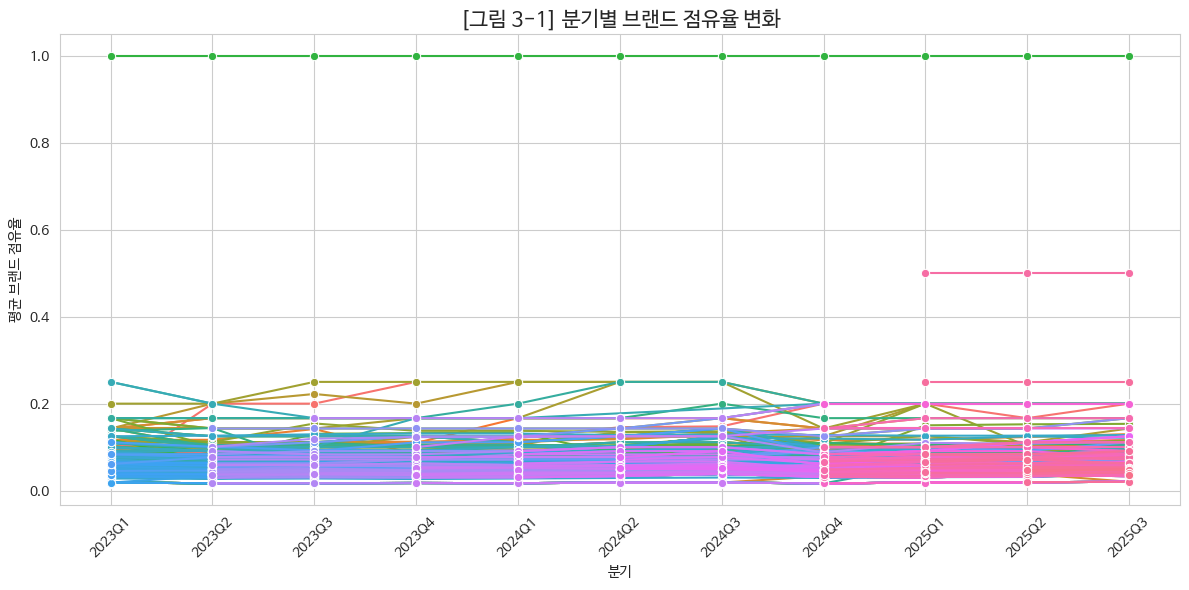

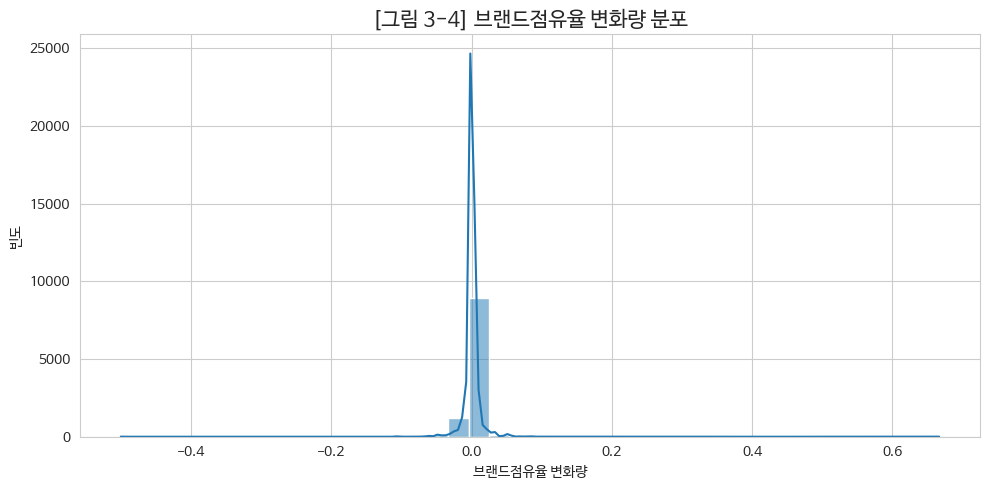

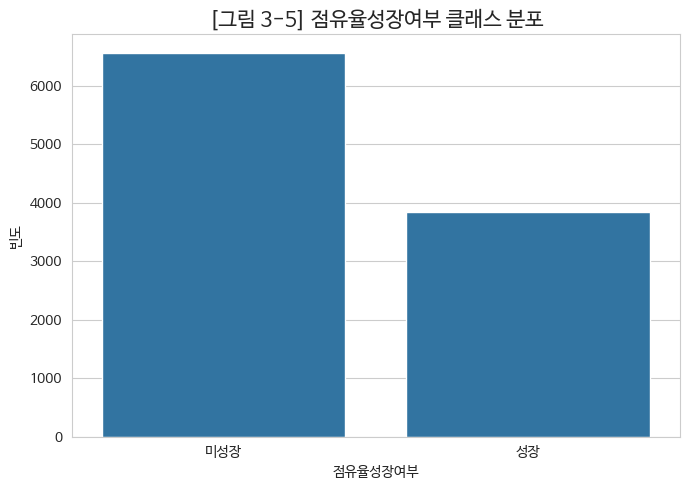

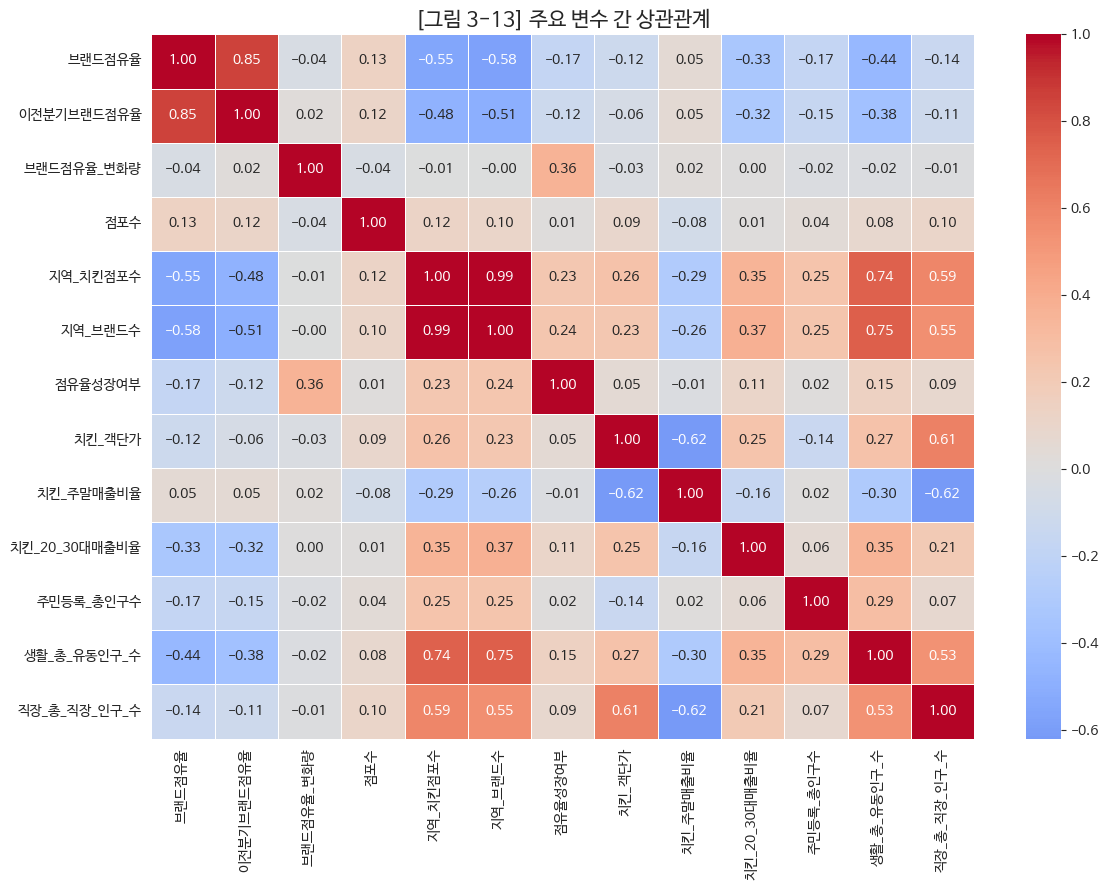

In [ ]:
fig_3_1 = model_df.groupby(['분기', '브랜드'], as_index=False)['브랜드점유율'].mean()
plt.figure(figsize=(12, 6))
sns.lineplot(data=fig_3_1, x='분기', y='브랜드점유율', hue='브랜드', marker='o', legend=False)
plt.title('[그림 3-1] 분기별 브랜드 점유율 변화', fontsize=15)
plt.xlabel('분기')
plt.ylabel('평균 브랜드 점유율')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-1_분기별_브랜드_점유율_변화.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(model_df['브랜드점유율_변화량'], bins=40, kde=True)
plt.title('[그림 3-4] 브랜드점유율 변화량 분포', fontsize=15)
plt.xlabel('브랜드점유율 변화량')
plt.ylabel('빈도')
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-4_브랜드점유율_변화량_분포.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=model_df, x='점유율성장여부')
plt.title('[그림 3-5] 점유율성장여부 클래스 분포', fontsize=15)
plt.xlabel('점유율성장여부')
plt.ylabel('빈도')
plt.xticks([0, 1], ['미성장', '성장'])
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-5_점유율성장여부_클래스_분포.png', dpi=300, bbox_inches='tight')
plt.show()

corr_candidates = [
    '브랜드점유율', '이전분기브랜드점유율', '브랜드점유율_변화량',
    '점포수', '지역_치킨점포수', '지역_브랜드수', '점유율성장여부',
    '치킨_객단가', '치킨_주말매출비율', '치킨_20_30대매출비율',
    '주민등록_총인구수', '생활_총_유동인구_수', '직장_총_직장_인구_수'
]
corr_cols = [c for c in corr_candidates if c in model_df.columns]
plt.figure(figsize=(12, 9))
sns.heatmap(model_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('[그림 3-13] 주요 변수 간 상관관계', fontsize=15)
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-13_주요_변수_상관관계.png', dpi=300, bbox_inches='tight')
plt.show()


### 13-3. 보고서 3장 표·그림 저장: 모델 성능


,model,threshold,accuracy,precision,recall,f1,predicted_growth_count,roc_auc,pr_auc
2,CatBoost,0.20,0.509091,0.391662,0.819160,0.529944,1943,0.579409,0.438536
1,XGBoost,0.10,0.390909,0.352219,0.956943,0.514915,2524,0.551274,0.402403
0,RandomForest,0.05,0.338182,0.337941,1.000000,0.505166,2749,0.556943,0.415167


,model,mae,rmse,r2
1,XGBoost,0.005384,0.010499,-0.233671
0,RandomForest,0.005860,0.010767,-0.297543
2,CatBoost,0.005321,0.011551,-0.493216


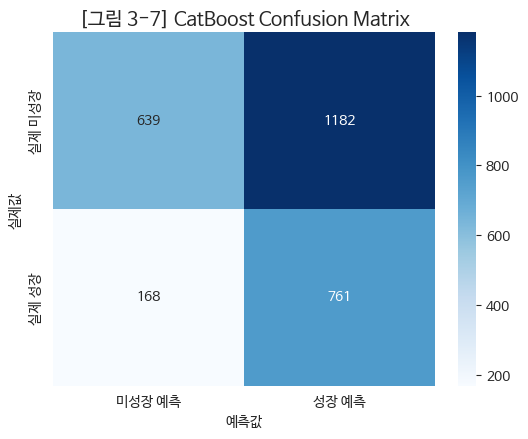

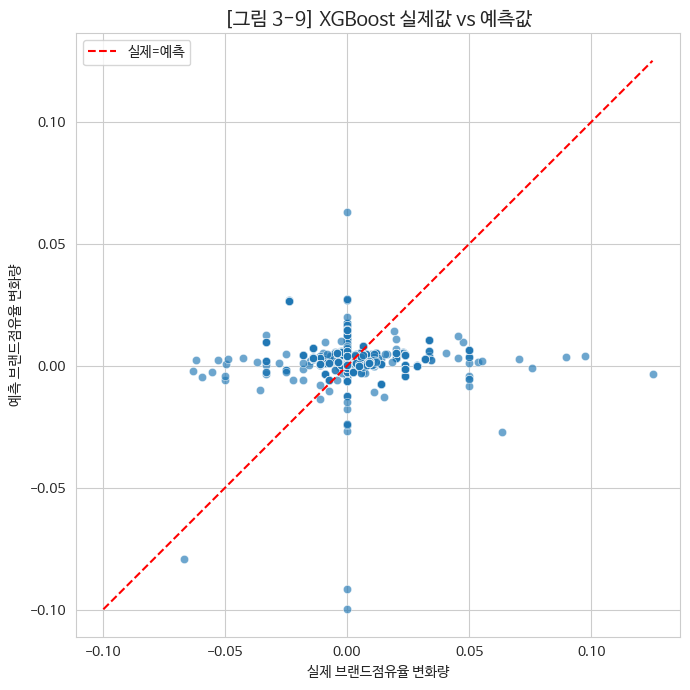

In [ ]:
report_table_3_1 = final_cls_metrics.copy()
report_table_3_1.to_csv(REPORT_DIR / '표_3-1_분류_모델_성능_비교.csv', index=False, encoding='utf-8-sig')
display(report_table_3_1)

report_table_3_2 = final_reg_metrics.copy()
report_table_3_2.to_csv(REPORT_DIR / '표_3-2_회귀_모델_성능_비교.csv', index=False, encoding='utf-8-sig')
display(report_table_3_2)

best_cls_model = final_cls_metrics.sort_values('f1', ascending=False).iloc[0]['model']
best_cls_pred = cls_preds[cls_preds['model'] == best_cls_model].copy()
cm = confusion_matrix(best_cls_pred['점유율성장여부'], best_cls_pred['pred_growth'])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['미성장 예측', '성장 예측'], yticklabels=['실제 미성장', '실제 성장'])
plt.title(f'[그림 3-7] {best_cls_model} Confusion Matrix', fontsize=14)
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-7_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

best_reg_model = final_reg_metrics.sort_values('rmse').iloc[0]['model']
best_reg_pred = reg_preds[reg_preds['model'] == best_reg_model].copy()
plt.figure(figsize=(7, 7))
sns.scatterplot(data=best_reg_pred, x='브랜드점유율_변화량', y='pred_change', alpha=0.65)
min_v = min(best_reg_pred['브랜드점유율_변화량'].min(), best_reg_pred['pred_change'].min())
max_v = max(best_reg_pred['브랜드점유율_변화량'].max(), best_reg_pred['pred_change'].max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label='실제=예측')
plt.title(f'[그림 3-9] {best_reg_model} 실제값 vs 예측값', fontsize=14)
plt.xlabel('실제 브랜드점유율 변화량')
plt.ylabel('예측 브랜드점유율 변화량')
plt.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-9_실제값_vs_예측값.png', dpi=300, bbox_inches='tight')
plt.show()


### 13-4. 보고서 3장 그림 저장: Feature Importance


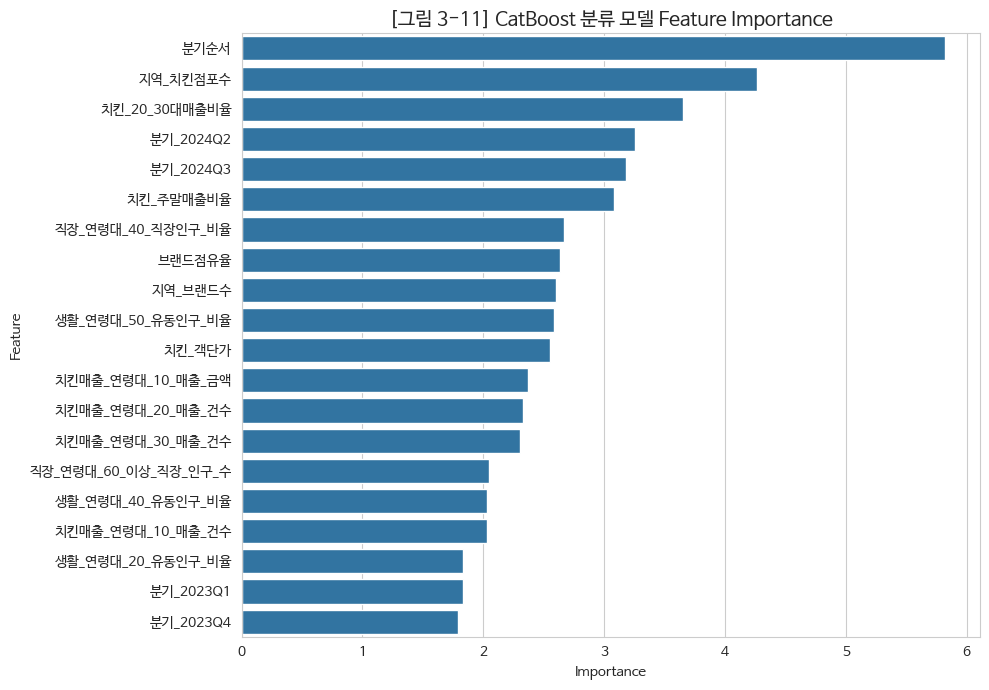

,feature,importance
753,분기순서,5.819497
694,지역_치킨점포수,4.267826
752,치킨_20_30대매출비율,3.649930
690,분기_2024Q2,3.256621
691,분기_2024Q3,3.179322
751,치킨_주말매출비율,3.082898
727,직장_연령대_40_직장인구_비율,2.666367
696,브랜드점유율,2.635955
695,지역_브랜드수,2.602788
715,생활_연령대_50_유동인구_비율,2.586834


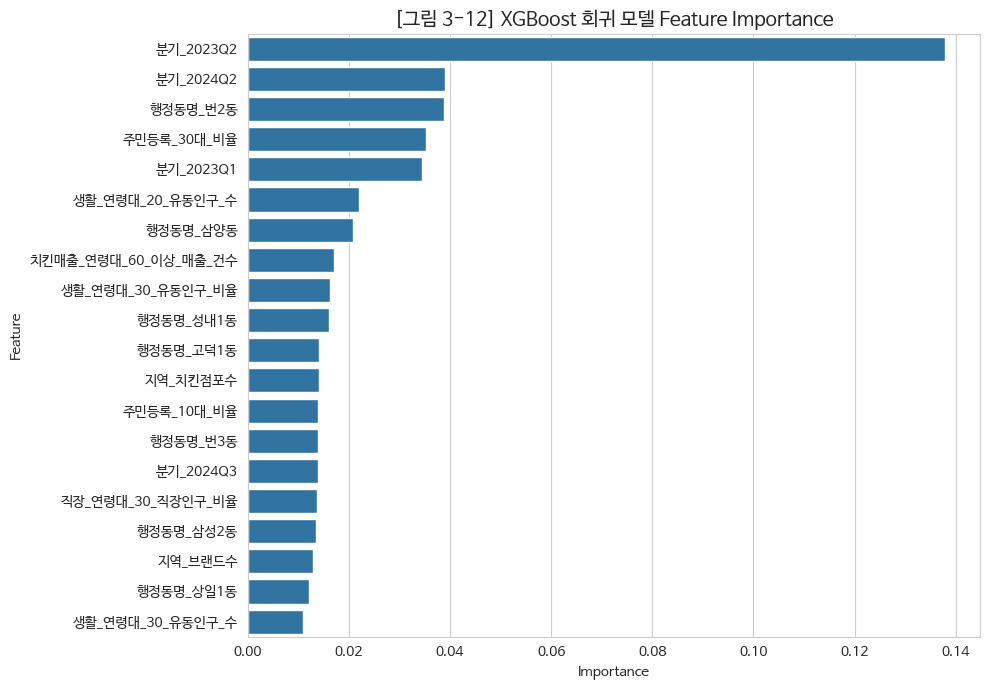

,feature,importance
686,분기_2023Q2,0.137898
690,분기_2024Q2,0.039114
34,행정동명_번2동,0.038810
700,주민등록_30대_비율,0.035251
685,분기_2023Q1,0.034377
706,생활_연령대_20_유동인구_수,0.022014
39,행정동명_삼양동,0.020749
749,치킨매출_연령대_60_이상_매출_건수,0.017137
713,생활_연령대_30_유동인구_비율,0.016262
42,행정동명_성내1동,0.016091


In [ ]:
def _report_feature_names_from_pipeline(pipeline, categorical_features, numeric_features):
    preprocessor = pipeline.named_steps['preprocess']
    cat_encoder = preprocessor.named_transformers_['cat']
    cat_names = cat_encoder.get_feature_names_out(categorical_features)
    return np.concatenate([cat_names, numeric_features])

def _report_feature_importance(model_dict, model_name, categorical_features, numeric_features, top_n=20):
    pipeline = model_dict[model_name]
    feature_names = _report_feature_names_from_pipeline(pipeline, categorical_features, numeric_features)
    estimator = pipeline.named_steps['model']
    importance = estimator.feature_importances_
    fi = pd.DataFrame({'feature': feature_names, 'importance': importance})
    return fi.sort_values('importance', ascending=False).head(top_n)

best_tree_cls = final_cls_metrics[final_cls_metrics['model'].isin(['RandomForest', 'XGBoost', 'CatBoost'])].sort_values('f1', ascending=False).iloc[0]['model']
report_cls_fi = _report_feature_importance(classification_models, best_tree_cls, categorical_features, numeric_features, top_n=20)
report_cls_fi.to_csv(REPORT_DIR / '표_3-11_분류_모델_Feature_Importance_상위.csv', index=False, encoding='utf-8-sig')
plt.figure(figsize=(10, 7))
sns.barplot(data=report_cls_fi, x='importance', y='feature')
plt.title(f'[그림 3-11] {best_tree_cls} 분류 모델 Feature Importance', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-11_분류_모델_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()
display(report_cls_fi)

best_tree_reg = final_reg_metrics[final_reg_metrics['model'].isin(['RandomForest', 'XGBoost', 'CatBoost'])].sort_values('rmse').iloc[0]['model']
report_reg_fi = _report_feature_importance(regression_models, best_tree_reg, categorical_features, numeric_features, top_n=20)
report_reg_fi.to_csv(REPORT_DIR / '표_3-12_회귀_모델_Feature_Importance_상위.csv', index=False, encoding='utf-8-sig')
plt.figure(figsize=(10, 7))
sns.barplot(data=report_reg_fi, x='importance', y='feature')
plt.title(f'[그림 3-12] {best_tree_reg} 회귀 모델 Feature Importance', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(REPORT_DIR / '그림_3-12_회귀_모델_Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()
display(report_reg_fi)


### 13-5. 보고서 3장 표 저장: 잘 맞힌 사례 / 틀린 사례


In [ ]:
best_cls_cases = cls_preds[cls_preds['model'] == best_cls_model].copy()
correct_cls = best_cls_cases[best_cls_cases['correct']].sort_values('growth_proba', ascending=False).head(10)
best_reg_cases = reg_preds[reg_preds['model'] == best_reg_model].copy()
correct_reg = best_reg_cases.sort_values('abs_error', ascending=True).head(10)

report_table_3_3_cls = correct_cls[['model', '분기', '시군구명', '행정동명', '브랜드', '브랜드점유율', '브랜드점유율_변화량', '점유율성장여부', 'pred_growth', 'growth_proba']]
report_table_3_3_reg = correct_reg[['model', '분기', '시군구명', '행정동명', '브랜드', '브랜드점유율_변화량', 'pred_change', 'abs_error']]
report_table_3_3_cls.to_csv(REPORT_DIR / '표_3-3_분류_잘_맞힌_사례.csv', index=False, encoding='utf-8-sig')
report_table_3_3_reg.to_csv(REPORT_DIR / '표_3-3_회귀_잘_맞힌_사례.csv', index=False, encoding='utf-8-sig')
print('[표 3-3] 분류 모델 잘 맞힌 사례')
display(report_table_3_3_cls)
print('[표 3-3] 회귀 모델 잘 맞힌 사례')
display(report_table_3_3_reg)

wrong_cls = best_cls_cases[~best_cls_cases['correct']].copy()
wrong_cls['error_type'] = np.where(
    (wrong_cls['점유율성장여부'] == 1) & (wrong_cls['pred_growth'] == 0),
    '실제 성장인데 미성장으로 예측',
    '실제 미성장인데 성장으로 예측'
)
wrong_cls = wrong_cls.sort_values('growth_proba', ascending=False).head(10)
wrong_reg = best_reg_cases.sort_values('abs_error', ascending=False).head(10)

report_table_3_5_cls = wrong_cls[['model', '분기', '시군구명', '행정동명', '브랜드', '브랜드점유율', '브랜드점유율_변화량', '점유율성장여부', 'pred_growth', 'growth_proba', 'error_type']]
report_table_3_5_reg = wrong_reg[['model', '분기', '시군구명', '행정동명', '브랜드', '브랜드점유율_변화량', 'pred_change', 'abs_error']]
report_table_3_5_cls.to_csv(REPORT_DIR / '표_3-5_분류_틀린_사례.csv', index=False, encoding='utf-8-sig')
report_table_3_5_reg.to_csv(REPORT_DIR / '표_3-5_회귀_틀린_사례.csv', index=False, encoding='utf-8-sig')
print('[표 3-5] 분류 모델 틀린 사례')
display(report_table_3_5_cls)
print('[표 3-5] 회귀 모델 틀린 사례')
display(report_table_3_5_reg)


[표 3-3] 분류 모델 잘 맞힌 사례


,model,분기,시군구명,행정동명,브랜드,브랜드점유율,브랜드점유율_변화량,점유율성장여부,pred_growth,growth_proba
6099,CatBoost,2025Q1,강남구,역삼1동,나이티지,0.037037,0.001425,1,1,0.944999
6067,CatBoost,2025Q1,강남구,역삼1동,BBQ,0.037037,0.001425,1,1,0.941921
6068,CatBoost,2025Q2,강남구,역삼1동,BBQ,0.038462,0.002355,1,1,0.941714
6186,CatBoost,2025Q1,강남구,역삼1동,한앤둘치킨,0.037037,0.001425,1,1,0.940077
6187,CatBoost,2025Q2,강남구,역삼1동,한앤둘치킨,0.038462,0.002355,1,1,0.939864
6079,CatBoost,2025Q1,강남구,역삼1동,교촌치킨,0.037037,0.001425,1,1,0.936831
6080,CatBoost,2025Q2,강남구,역삼1동,교촌치킨,0.038462,0.002355,1,1,0.936608
6095,CatBoost,2025Q2,강남구,역삼1동,꼭그닭,0.019231,0.001177,1,1,0.936594
6118,CatBoost,2025Q2,강남구,역삼1동,돈치킨,0.019231,0.001177,1,1,0.936594
6160,CatBoost,2025Q2,강남구,역삼1동,이케이푸드,0.019231,0.001177,1,1,0.936594


[표 3-3] 회귀 모델 잘 맞힌 사례


,model,분기,시군구명,행정동명,브랜드,브랜드점유율_변화량,pred_change,abs_error
3968,XGBoost,2025Q1,강동구,암사1동,굽네치킨,0.000000,4.186545e-07,4.186545e-07
3565,XGBoost,2025Q3,강동구,강일동,교촌치킨,0.000000,-1.828880e-05,1.828880e-05
3992,XGBoost,2025Q1,강동구,암사1동,썬더치킨,0.000000,3.378293e-05,3.378293e-05
2785,XGBoost,2025Q3,강남구,개포4동,BHC,0.000000,4.153974e-05,4.153974e-05
3737,XGBoost,2025Q1,강동구,둔촌2동,굽네치킨,0.000000,-6.000963e-05,6.000963e-05
4989,XGBoost,2025Q1,강서구,방화1동,가마로강정,0.001008,1.068775e-03,6.071044e-05
4979,XGBoost,2025Q1,강서구,방화1동,1번지통닭,0.001008,1.068775e-03,6.071044e-05
5044,XGBoost,2025Q1,강서구,방화1동,푸라닭,0.001008,1.068775e-03,6.071044e-05
5027,XGBoost,2025Q1,강서구,방화1동,장터즉석치킨,0.001008,1.068775e-03,6.071044e-05
5005,XGBoost,2025Q1,강서구,방화1동,두드림치킨,0.001008,1.068775e-03,6.071044e-05


[표 3-5] 분류 모델 틀린 사례


,model,분기,시군구명,행정동명,브랜드,브랜드점유율,브랜드점유율_변화량,점유율성장여부,pred_growth,growth_proba,error_type
6101,CatBoost,2025Q3,강남구,역삼1동,나이티지,0.020408,-0.000408,0,1,0.951712,실제 미성장인데 성장으로 예측
6100,CatBoost,2025Q2,강남구,역삼1동,나이티지,0.038462,-0.018053,0,1,0.944803,실제 미성장인데 성장으로 예측
7987,CatBoost,2025Q1,강서구,화곡1동,화신바베큐치킨,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7984,CatBoost,2025Q1,강서구,화곡1동,홈웰빙치킨,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7975,CatBoost,2025Q1,강서구,화곡1동,통닭왕,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7972,CatBoost,2025Q1,강서구,화곡1동,치킨몬스터,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7969,CatBoost,2025Q1,강서구,화곡1동,치킨내킨,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7955,CatBoost,2025Q1,강서구,화곡1동,옛날통닭,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7961,CatBoost,2025Q1,강서구,화곡1동,와커치킨,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측
7958,CatBoost,2025Q1,강서구,화곡1동,와치킨,0.043478,0.000000,0,1,0.936392,실제 미성장인데 성장으로 예측


[표 3-5] 회귀 모델 틀린 사례


,model,분기,시군구명,행정동명,브랜드,브랜드점유율_변화량,pred_change,abs_error
4340,XGBoost,2025Q1,강북구,삼양동,BBQ,0.125000,-0.003168,0.128168
3797,XGBoost,2025Q1,강동구,명일2동,네네치킨,0.000000,-0.099748,0.099748
4284,XGBoost,2025Q1,강북구,번3동,BBQ,0.097222,0.003889,0.093333
3798,XGBoost,2025Q2,강동구,명일2동,네네치킨,0.000000,-0.091576,0.091576
4285,XGBoost,2025Q2,강북구,번3동,BBQ,0.063492,-0.026925,0.090417
4308,XGBoost,2025Q1,강북구,삼각산동,BBQ,0.089744,0.003687,0.086056
4844,XGBoost,2025Q3,강서구,등촌1동,푸라닭,0.075758,-0.000767,0.076524
4245,XGBoost,2025Q1,강북구,번1동,BBQ,0.070513,0.002866,0.067647
3756,XGBoost,2025Q3,강동구,명일1동,BBQ,-0.061905,0.002227,0.064131
4283,XGBoost,2025Q3,강북구,번2동,굽네치킨,0.000000,0.063134,0.063134


### 13-6. 보고서 4장 표 저장: 결론


In [ ]:
report_table_4_1 = pd.DataFrame([
    {'결론 항목':'브랜드 점유율 예측 가능성', '분석 근거':'분기 및 지역·브랜드별 점포수와 상권 변수를 이용해 성장 여부를 예측', '활용 방안':'출점 후보 지역 및 브랜드 전략 수립'},
    {'결론 항목':'상권 특성 반영 필요', '분석 근거':'생활인구와 직장인구, 매출 특성이 모델 입력 변수로 활용됨', '활용 방안':'지역 수요 특성에 맞춘 입지 평가'},
    {'결론 항목':'경쟁 구조의 중요성', '분석 근거':'지역_치킨점포수, 지역_브랜드수, 브랜드점유율 등이 주요 변수로 포함', '활용 방안':'경쟁 강도 및 시장 포화도 판단'},
    {'결론 항목':'데이터 품질 관리 필요', '분석 근거':'브랜드명, 행정동명, 분기 표기 정규화가 분석 결과에 영향', '활용 방안':'지속적인 데이터 정제 체계 마련'},
    {'결론 항목':'해석 가능한 모델 활용', '분석 근거':'트리 기반 모델의 Feature Importance 확인', '활용 방안':'예측 결과의 원인 설명 및 의사결정 지원'},
])
report_table_4_1.to_csv(REPORT_DIR / '표_4-1_결론_및_활용_방안.csv', index=False, encoding='utf-8-sig')
display(report_table_4_1)

print('보고서용 자산 생성 완료')
for p in sorted(REPORT_DIR.glob('*')):
    print(p.name)


,결론 항목,분석 근거,활용 방안
0,브랜드 점유율 예측 가능성,분기 및 지역·브랜드별 점포수와 상권 변수를 이용해 성장 여부를 예측,출점 후보 지역 및 브랜드 전략 수립
1,상권 특성 반영 필요,"생활인구와 직장인구, 매출 특성이 모델 입력 변수로 활용됨",지역 수요 특성에 맞춘 입지 평가
2,경쟁 구조의 중요성,"지역_치킨점포수, 지역_브랜드수, 브랜드점유율 등이 주요 변수로 포함",경쟁 강도 및 시장 포화도 판단
3,데이터 품질 관리 필요,"브랜드명, 행정동명, 분기 표기 정규화가 분석 결과에 영향",지속적인 데이터 정제 체계 마련
4,해석 가능한 모델 활용,트리 기반 모델의 Feature Importance 확인,예측 결과의 원인 설명 및 의사결정 지원


보고서용 자산 생성 완료
그림_3-11_분류_모델_Feature_Importance.png
그림_3-12_회귀_모델_Feature_Importance.png
그림_3-13_주요_변수_상관관계.png
그림_3-1_분기별_브랜드_점유율_변화.png
그림_3-4_브랜드점유율_변화량_분포.png
그림_3-5_점유율성장여부_클래스_분포.png
그림_3-7_Confusion_Matrix.png
그림_3-9_실제값_vs_예측값.png
표_2-1_원천_데이터_구성.csv
표_2-2_데이터_전처리_과정.csv
표_2-4_Feature_Target_변수_정의.csv
표_2-7_학습_검증_테스트_데이터_분할.csv
표_3-11_분류_모델_Feature_Importance_상위.csv
표_3-12_회귀_모델_Feature_Importance_상위.csv
표_3-1_분류_모델_성능_비교.csv
표_3-2_회귀_모델_성능_비교.csv
표_3-3_분류_잘_맞힌_사례.csv
표_3-3_회귀_잘_맞힌_사례.csv
표_3-5_분류_틀린_사례.csv
표_3-5_회귀_틀린_사례.csv
표_4-1_결론_및_활용_방안.csv
